In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# Ruta del archivo ROOT
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

# Abrir el archivo
root_file = uproot.open(file_path)

# Mostrar los árboles que contiene
print("Árboles y claves en el ROOT file:")
for key in root_file.keys():
    print(key)


Árboles y claves en el ROOT file:
peak;33
spectrum;9
temp;6


In [29]:
# Imports necesarios para el análisis
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

print("✅ Librerías importadas correctamente\n")

# --- Explorar estructura del archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
print(f"📁 Archivo ROOT: {input_filename}\n")

with uproot.open(input_filename) as file:
    print("=" * 60)
    print("🌲 ÁRBOLES (TREES) DISPONIBLES EN EL ARCHIVO:")
    print("=" * 60)
    
    # Listar todos los keys y filtrar TTree
    all_keys = list(file.keys())
    print(f"\nKeys encontrados: {all_keys}\n")
    
    # Identificar trees (objetos TTree)
    trees_dict = {}
    for key in file.keys():
        obj = file[key]
        if hasattr(obj, 'num_entries'):  # Es un TTree
            tree_name = key.split(';')[0]  # Quitar versión
            trees_dict[tree_name] = obj
    
    # Mostrar información de cada árbol
    for tree_name, tree in trees_dict.items():
        print(f"\n  📊 Tree: {tree_name}")
        print(f"      Entradas (filas): {tree.num_entries:,}")
        print(f"      Ramas (branches): {len(tree.keys())}")
        print(f"      Lista de ramas:")
        
        # Mostrar ramas y sus tipos
        for branch_name in tree.keys():
            branch = tree[branch_name]
            branch_type = branch.typename
            # Si es array, mostrar dimensiones
            try:
                interpretation = branch.interpretation
                print(f"        • {branch_name:15s} → {branch_type:30s} {interpretation}")
            except:
                print(f"        • {branch_name:15s} → {branch_type}")
    
    print("\n" + "=" * 60)
    print("📋 EJEMPLO DE CONTENIDO (primeras 5 filas):")
    print("=" * 60)
    
    # Mostrar contenido de ejemplo para cada árbol
    for tree_name, tree in trees_dict.items():
        print(f"\n  🔍 Tree: {tree_name}")
        data = tree.arrays(library="np", entry_stop=5)  # Primeras 5 filas
        
        for key, values in data.items():
            print(f"\n      📌 Branch: {key}")
            print(f"         Shape: {values.shape}")
            
            if len(values.shape) > 1:
                # Array multidimensional - mostrar primeras filas
                print(f"         Dimensiones: {values.shape}")
                print(f"         Primeras 3 entradas:")
                for i in range(min(3, len(values))):
                    print(f"           [{i}]: {values[i]}")
            else:
                # Array 1D - mostrar valores
                print(f"         Valores: {values[:5]}")
    
    print("\n" + "=" * 60)
    print("ℹ️  Los datos completos se cargarán y procesarán en celdas siguientes")
    print("=" * 60)

✅ Librerías importadas correctamente

📁 Archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root

🌲 ÁRBOLES (TREES) DISPONIBLES EN EL ARCHIVO:

Keys encontrados: ['peak;33', 'spectrum;9', 'temp;6']


  📊 Tree: peak
      Entradas (filas): 7,553,875
      Ramas (branches): 5
      Lista de ramas:
        • t               → double[2]                      AsDtype("('>f8', (2,))")
        • wav             → double[2][5]                   AsDtype("('>f8', (2, 5))")
        • sweep           → double[2][5]                   AsDtype("('>f8', (2, 5))")
        • ch              → double[5]                      AsDtype("('>f8', (5,))")
        • pos             → double[5]                      AsDtype("('>f8', (5,))")

  📊 Tree: spectrum
      Entradas (filas): 1,010
      Ramas (branches): 2
      Lista de ramas:
        • t               → double[2]                      AsDtype("('>f8', (2,))")
        • wav             → double[2][3][39200]            AsDtype("('>f8', (2,

In [4]:
import uproot
import numpy as np

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    spectrum_tree = file["spectrum"]
    temp_tree = file["temp"]
    
    # Cargar ramas como numpy arrays
    peak_data = peak_tree.arrays(library="np")
    spectrum_data = spectrum_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Imprimir shapes de todas las variables ---
print("=== peak ===")
for key, value in peak_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== spectrum ===")
for key, value in spectrum_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== temp ===")
for key, value in temp_data.items():
    print(f"{key}: {np.array(value).shape}")



=== peak ===
t: (7553875, 2)
t: (7553875, 2)
wav: (7553875, 2, 5)
wav: (7553875, 2, 5)
sweep: (7553875, 2, 5)
sweep: (7553875, 2, 5)
ch: (7553875, 5)
ch: (7553875, 5)
pos: (7553875, 5)

=== spectrum ===
t: (1010, 2)
pos: (7553875, 5)

=== spectrum ===
t: (1010, 2)
wav: (1010, 2, 3, 39200)

=== temp ===
t: (20554,)
temp: (20554, 5)
wav: (1010, 2, 3, 39200)

=== temp ===
t: (20554,)
temp: (20554, 5)


---- INTERVALO DE DATOS (SIN CORRECCIÓN) ----
Peak data: 2025-11-19 14:09:59.167192  →  2025-11-20 07:01:53.775902
Temp data: 2025-11-19 16:04:25  →  2025-11-19 23:55:40
---------------------------------------------

⚠️  DESFASE TEMPORAL DETECTADO:
Diferencia entre inicio de Temp y Peak: 1:54:25.832808
Diferencia en horas: 1.91 h
→ Se debe aplicar corrección de +2h a los timestamps de Peak



/tmp/vgarciap/ipykernel_4182166/2097846455.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


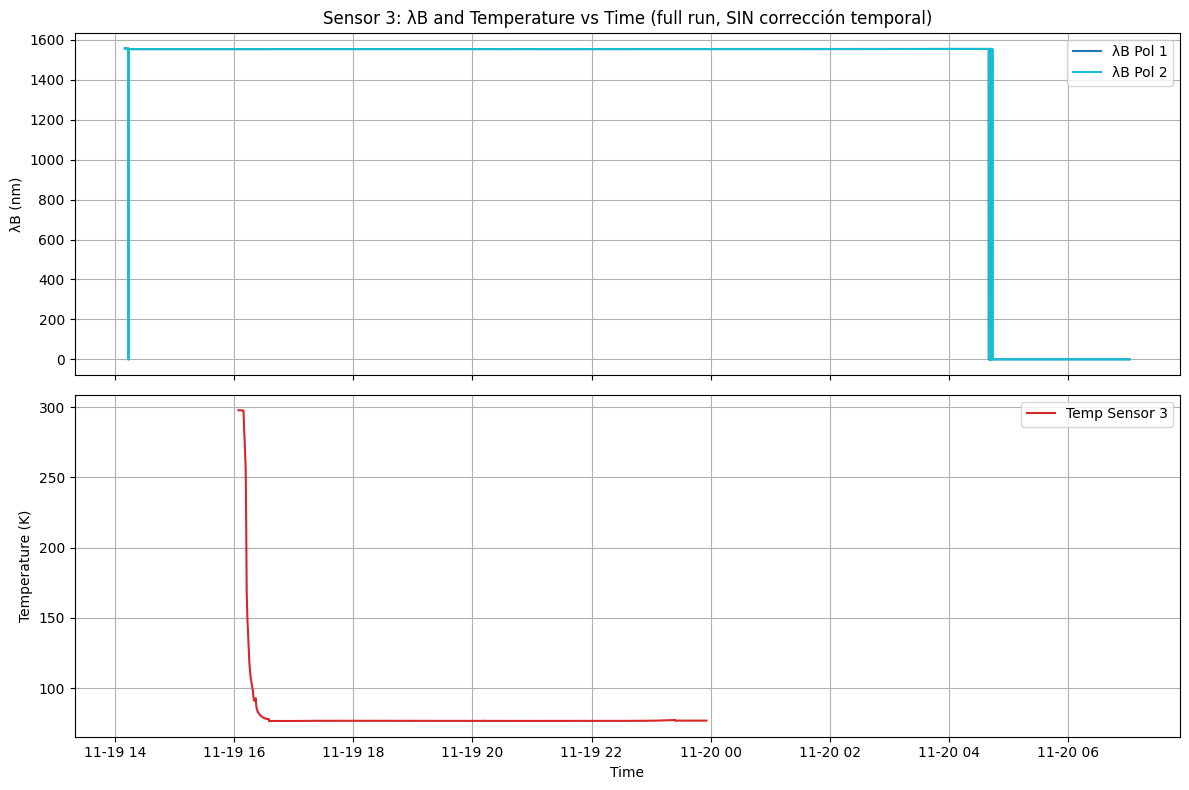

In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Mostrar inicio y fin del run ---
start_peak = np.min(peak_timestamps)
end_peak   = np.max(peak_timestamps)
start_temp = np.min(temp_timestamps)
end_temp   = np.max(temp_timestamps)

print("---- INTERVALO DE DATOS (SIN CORRECCIÓN) ----")
print(f"Peak data: {start_peak}  →  {end_peak}")
print(f"Temp data: {start_temp}  →  {end_temp}")
print("---------------------------------------------")

# --- Calcular diferencia de tiempo entre peak y temp ---
time_diff = start_temp - start_peak
time_diff_hours = time_diff.total_seconds() / 3600

print(f"\n⚠️  DESFASE TEMPORAL DETECTADO:")
print(f"Diferencia entre inicio de Temp y Peak: {time_diff}")
print(f"Diferencia en horas: {time_diff_hours:.2f} h")
print(f"→ Se debe aplicar corrección de +{time_diff_hours:.0f}h a los timestamps de Peak\n")

# --- Graficar en dos subplots (todo el rango) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB (Bragg)
ax1.plot(peak_timestamps, sensor3_pol1*1e9, label="λB Pol 1", color="tab:blue")
ax1.plot(peak_timestamps, sensor3_pol2*1e9, label="λB Pol 2", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (full run, SIN corrección temporal)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_timestamps, sensor3_temp, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

DATA WITH TIME CORRECTION (+2h shift applied to Peak data)
Peak data (shifted): 2025-11-19 16:09:59.167191982  →  2025-11-20 09:01:53.775902033
Temp data (no shift): 2025-11-19 16:04:25  →  2025-11-19 23:55:40

🔍 AFTER FILTERING NEGATIVES/ZEROS:
  Peak data now ends at:  2025-11-20 06:42:37.055689096
  Temp data still ends at: 2025-11-19 23:55:40

🔄 TIME SYNCHRONIZATION:
  Peak filtered data ends at:  2025-11-20 06:42:37.055689096
  Temp filtered data ends at:  2025-11-19 23:55:40
  → Common end time (earliest): 2025-11-19 23:55:40
  → Truncating both series to:  2025-11-19 23:55:40

📊 FILTERING STATISTICS (negatives/zeros + time sync)

  Peak (wavelength):
    Total points: 7,553,875
    Valid points: 3,457,148 (45.8%)
    Removed points: 4,096,727 (54.2%)
    λB range: [1553.465, 1557.233] nm
    Time interval: 2025-11-19 16:09:59.167191982 → 2025-11-19 23:55:39.999856949

  Temperature:
    Total points: 20,554
    Valid points: 20,554 (100.0%)
    Removed points: 0 (0.0%)
    T ran

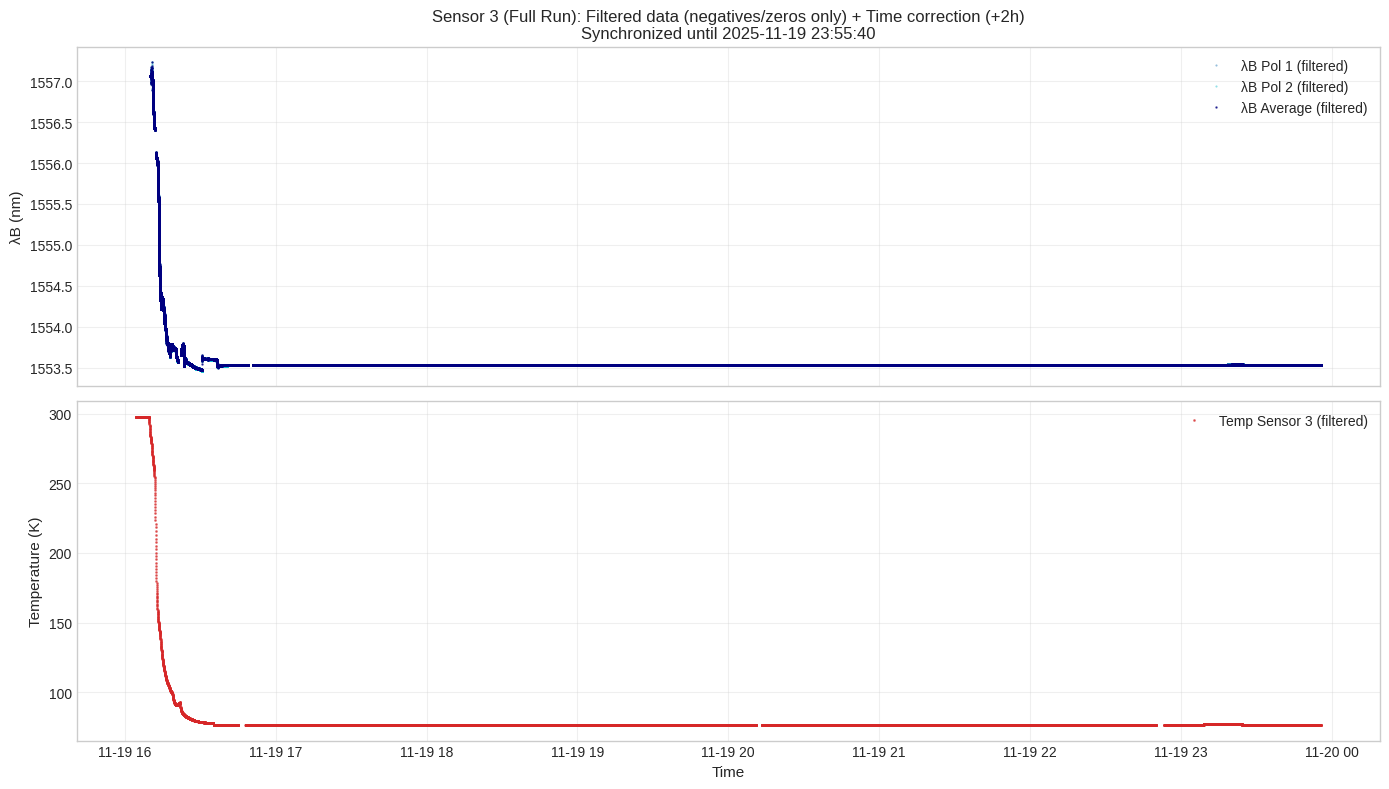

In [31]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert times to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- ✅ Apply +2h time correction to Peak data ---
time_shift = pd.Timedelta(hours=2)
peak_timestamps_shifted = peak_timestamps + time_shift

print("=" * 70)
print("DATA WITH TIME CORRECTION (+2h shift applied to Peak data)")
print("=" * 70)
print(f"Peak data (shifted): {peak_timestamps_shifted.min()}  →  {peak_timestamps_shifted.max()}")
print(f"Temp data (no shift): {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("=" * 70 + "\n")

# --- FILTER ONLY NEGATIVES AND ZEROS (no outlier removal) ---
# Average of polarizations
sensor3_mean_raw = (sensor3_pol1 + sensor3_pol2) / 2

# Simple filtering: only remove zeros and negatives
mask_lambda_valid = (
    (sensor3_pol1 > 0) &  # No negatives or zeros in pol1
    (sensor3_pol2 > 0) &  # No negatives or zeros in pol2
    (sensor3_mean_raw > 0)  # No negatives or zeros in average
)

mask_temp_valid = (
    (sensor3_temp > 0)  # No negatives or zeros
)

# Apply initial masks
peak_timestamps_filtered = peak_timestamps_shifted[mask_lambda_valid]
sensor3_pol1_filtered = sensor3_pol1[mask_lambda_valid]
sensor3_pol2_filtered = sensor3_pol2[mask_lambda_valid]
sensor3_mean_filtered = sensor3_mean_raw[mask_lambda_valid]

temp_timestamps_filtered = temp_timestamps[mask_temp_valid]
sensor3_temp_filtered = sensor3_temp[mask_temp_valid]

print("🔍 AFTER FILTERING NEGATIVES/ZEROS:")
print(f"  Peak data now ends at:  {peak_timestamps_filtered.max()}")
print(f"  Temp data still ends at: {temp_timestamps_filtered.max()}\n")

# --- TIME SYNCHRONIZATION: use earliest end time ---
peak_end = peak_timestamps_filtered.max()
temp_end = temp_timestamps_filtered.max()
common_end_time = min(peak_end, temp_end)

print("🔄 TIME SYNCHRONIZATION:")
print(f"  Peak filtered data ends at:  {peak_end}")
print(f"  Temp filtered data ends at:  {temp_end}")
print(f"  → Common end time (earliest): {common_end_time}")
print(f"  → Truncating both series to:  {common_end_time}\n")

# Truncate both series to common time
mask_peak_time = peak_timestamps_filtered <= common_end_time
mask_temp_time = temp_timestamps_filtered <= common_end_time

peak_timestamps_filtered = peak_timestamps_filtered[mask_peak_time]
sensor3_pol1_filtered = sensor3_pol1_filtered[mask_peak_time]
sensor3_pol2_filtered = sensor3_pol2_filtered[mask_peak_time]
sensor3_mean_filtered = sensor3_mean_filtered[mask_peak_time]

temp_timestamps_filtered = temp_timestamps_filtered[mask_temp_time]
sensor3_temp_filtered = sensor3_temp_filtered[mask_temp_time]

# --- Filtering statistics ---
n_peak_total = len(sensor3_pol1)
n_peak_filtered = len(sensor3_pol1_filtered)
n_peak_removed = n_peak_total - n_peak_filtered

n_temp_total = len(sensor3_temp)
n_temp_filtered = len(sensor3_temp_filtered)
n_temp_removed = n_temp_total - n_temp_filtered

print("=" * 70)
print("📊 FILTERING STATISTICS (negatives/zeros + time sync)")
print("=" * 70)
print(f"\n  Peak (wavelength):")
print(f"    Total points: {n_peak_total:,}")
print(f"    Valid points: {n_peak_filtered:,} ({100*n_peak_filtered/n_peak_total:.1f}%)")
print(f"    Removed points: {n_peak_removed:,} ({100*n_peak_removed/n_peak_total:.1f}%)")
print(f"    λB range: [{sensor3_mean_filtered.min()*1e9:.3f}, {sensor3_mean_filtered.max()*1e9:.3f}] nm")
print(f"    Time interval: {peak_timestamps_filtered.min()} → {peak_timestamps_filtered.max()}")

print(f"\n  Temperature:")
print(f"    Total points: {n_temp_total:,}")
print(f"    Valid points: {n_temp_filtered:,} ({100*n_temp_filtered/n_temp_total:.1f}%)")
print(f"    Removed points: {n_temp_removed:,} ({100*n_temp_removed/n_temp_total:.1f}%)")
print(f"    T range: [{sensor3_temp_filtered.min():.2f}, {sensor3_temp_filtered.max():.2f}] K")
print(f"    Time interval: {temp_timestamps_filtered.min()} → {temp_timestamps_filtered.max()}")
print("=" * 70 + "\n")

print("✅ Global variables defined and ready for subsequent cells:")
print("   - peak_timestamps_filtered (with +2h shift and synchronized)")
print("   - sensor3_pol1_filtered, sensor3_pol2_filtered, sensor3_mean_filtered")
print("   - temp_timestamps_filtered (synchronized)")
print("   - sensor3_temp_filtered")
print("   - common_end_time (common time boundary)")
print("\n⚠️  NOTE: Only negatives/zeros removed. Temperature changes preserved.\n")

# --- Plot filtered data (full run with time correction) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# λB (Bragg) - filtered data
ax1.plot(peak_timestamps_filtered, sensor3_pol1_filtered*1e9, '.', 
         label="λB Pol 1 (filtered)", color="tab:blue", markersize=1, alpha=0.5)
ax1.plot(peak_timestamps_filtered, sensor3_pol2_filtered*1e9, '.', 
         label="λB Pol 2 (filtered)", color="tab:cyan", markersize=1, alpha=0.5)
ax1.plot(peak_timestamps_filtered, sensor3_mean_filtered*1e9, '.', 
         label="λB Average (filtered)", color="navy", markersize=1.5, alpha=0.7)
ax1.set_ylabel("λB (nm)", fontsize=11)
ax1.set_title(f"Sensor 3 (Full Run): Filtered data (negatives/zeros only) + Time correction (+2h)\n" + 
              f"Synchronized until {common_end_time.strftime('%Y-%m-%d %H:%M:%S')}", fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Temperature - filtered data
ax2.plot(temp_timestamps_filtered, sensor3_temp_filtered, '.', 
         label="Temp Sensor 3 (filtered)", color="tab:red", markersize=2, alpha=0.6)
ax2.set_xlabel("Time", fontsize=11)
ax2.set_ylabel("Temperature (K)", fontsize=11)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

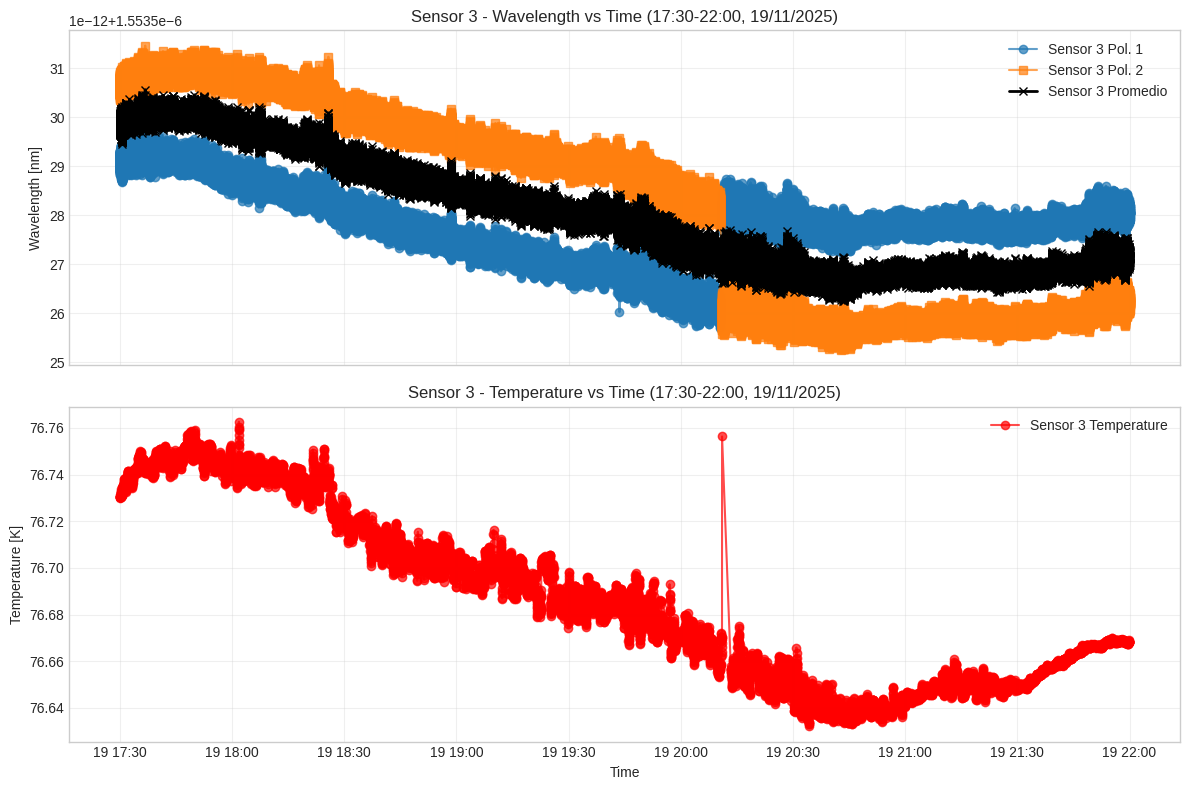

In [33]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- 💡 Corregir desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 11, 19, 17, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 22, 0, 0)

# --- Aplicar máscaras ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Calcular media de las dos polarizaciones ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2.0

# --- Graficar ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wavelength plot
ax1.plot(peak_t_filtered, sensor3_pol1_filtered, label="Sensor 3 Pol. 1", marker='o', linestyle='-', alpha=0.7)
ax1.plot(peak_t_filtered, sensor3_pol2_filtered, label="Sensor 3 Pol. 2", marker='s', linestyle='-', alpha=0.7)
ax1.plot(peak_t_filtered, sensor3_mean, label="Sensor 3 Promedio", marker='x', linestyle='-', linewidth=2, color='black')
ax1.set_ylabel("Wavelength [nm]")
ax1.set_title(f"Sensor 3 - Wavelength vs Time (17:30-22:00, 19/11/2025)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Temperature plot
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Sensor 3 Temperature", marker='o', linestyle='-', color='red', alpha=0.7)
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature [K]")
ax2.set_title(f"Sensor 3 - Temperature vs Time (17:30-22:00, 19/11/2025)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---- NUEVO INTERVALO DE DATOS ----
Peak data (shifted): 2025-11-19 16:09:59.167192  →  2025-11-20 09:01:53.775902
Temp data:            2025-11-19 16:04:25  →  2025-11-19 23:55:40
-----------------------------------


/tmp/vgarciap/ipykernel_4182166/879361822.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


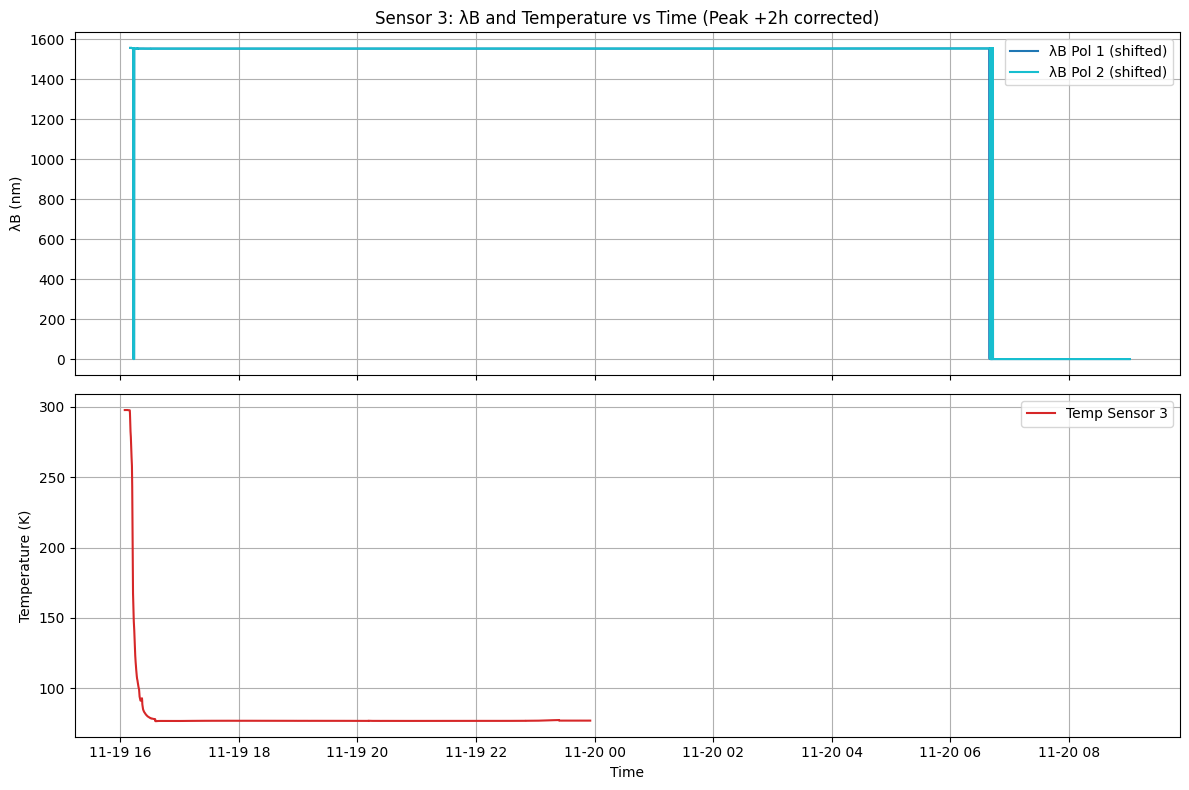

In [8]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Corregir el desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps_shifted = peak_timestamps + time_shift

# --- Mostrar nuevo intervalo ---
print("---- NUEVO INTERVALO DE DATOS ----")
print(f"Peak data (shifted): {peak_timestamps_shifted.min()}  →  {peak_timestamps_shifted.max()}")
print(f"Temp data:            {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("-----------------------------------")

# --- Graficar ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB (Bragg)
ax1.plot(peak_timestamps_shifted, sensor3_pol1*1e9, label="λB Pol 1 (shifted)", color="tab:blue")
ax1.plot(peak_timestamps_shifted, sensor3_pol2*1e9, label="λB Pol 2 (shifted)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (Peak +2h corrected)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_timestamps, sensor3_temp, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---- INTERVALO CORTADO ----
Peak data (shifted): 2025-11-19 16:09:59.167192 → 2025-11-19 23:24:59.998029
Temp data:           2025-11-19 16:04:25 → 2025-11-19 23:25:00
-----------------------------------


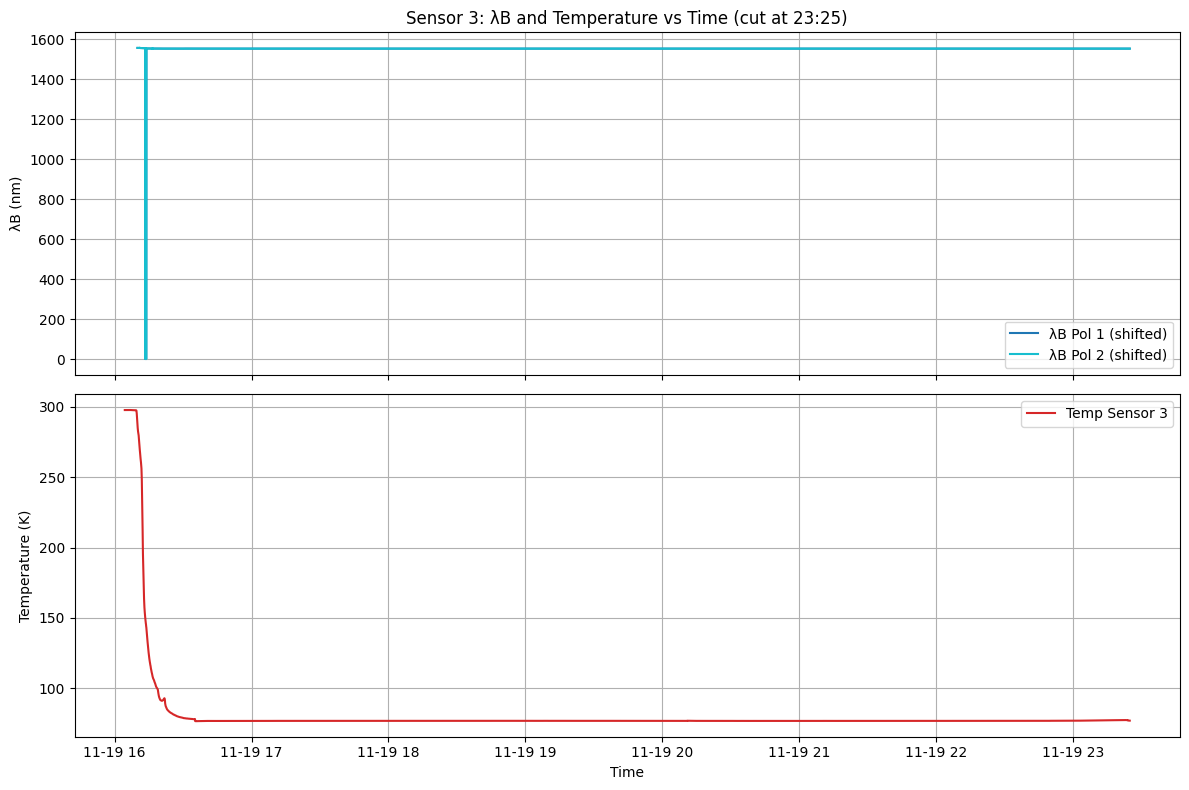

In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Corregir el desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps_shifted = peak_timestamps + time_shift

# --- Definir corte hasta las 23:25 ---
cut_time = datetime.datetime.combine(peak_timestamps_shifted[0].date(), datetime.time(hour=23, minute=25))

# --- Aplicar máscara de corte ---
mask_peak = peak_timestamps_shifted <= cut_time
mask_temp = temp_timestamps <= cut_time

peak_timestamps_cut = peak_timestamps_shifted[mask_peak]
sensor3_pol1_cut = sensor3_pol1[mask_peak]
sensor3_pol2_cut = sensor3_pol2[mask_peak]

temp_timestamps_cut = temp_timestamps[mask_temp]
sensor3_temp_cut = sensor3_temp[mask_temp]

# --- Mostrar nuevo intervalo ---
print("---- INTERVALO CORTADO ----")
print(f"Peak data (shifted): {peak_timestamps_cut.min()} → {peak_timestamps_cut.max()}")
print(f"Temp data:           {temp_timestamps_cut.min()} → {temp_timestamps_cut.max()}")
print("-----------------------------------")

# --- Graficar ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB (Bragg)
ax1.plot(peak_timestamps_cut, sensor3_pol1_cut*1e9, label="λB Pol 1 (shifted)", color="tab:blue")
ax1.plot(peak_timestamps_cut, sensor3_pol2_cut*1e9, label="λB Pol 2 (shifted)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (cut at 23:25)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_timestamps_cut, sensor3_temp_cut, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-19 16:09:59.167192  →  2025-11-20 09:01:53.775902
Temp data:       2025-11-19 16:04:25  →  2025-11-19 23:55:40
--------------------------------


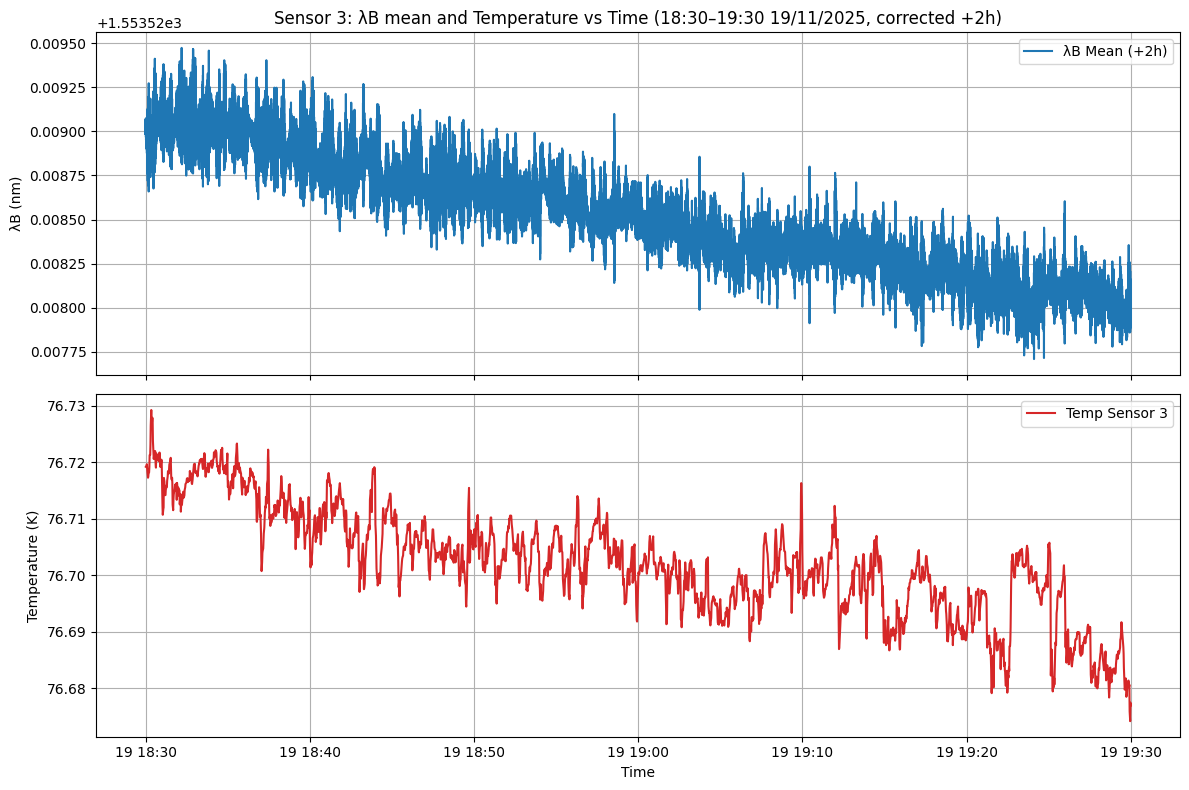

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Apply +2h correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Print data intervals ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_timestamps.min()}  →  {peak_timestamps.max()}")
print(f"Temp data:       {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("--------------------------------")

# --- Define time window for plotting ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

# --- Apply masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute mean polarization ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB mean
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="λB Mean (+2h)", color="tab:blue")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB mean and Temperature vs Time (18:30–19:30 19/11/2025, corrected +2h)")
ax1.legend()
ax1.grid(True)

# Temperature
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-19 16:09:59.167192  →  2025-11-20 09:01:53.775902
Temp data:       2025-11-19 16:04:25  →  2025-11-19 23:55:40
--------------------------------


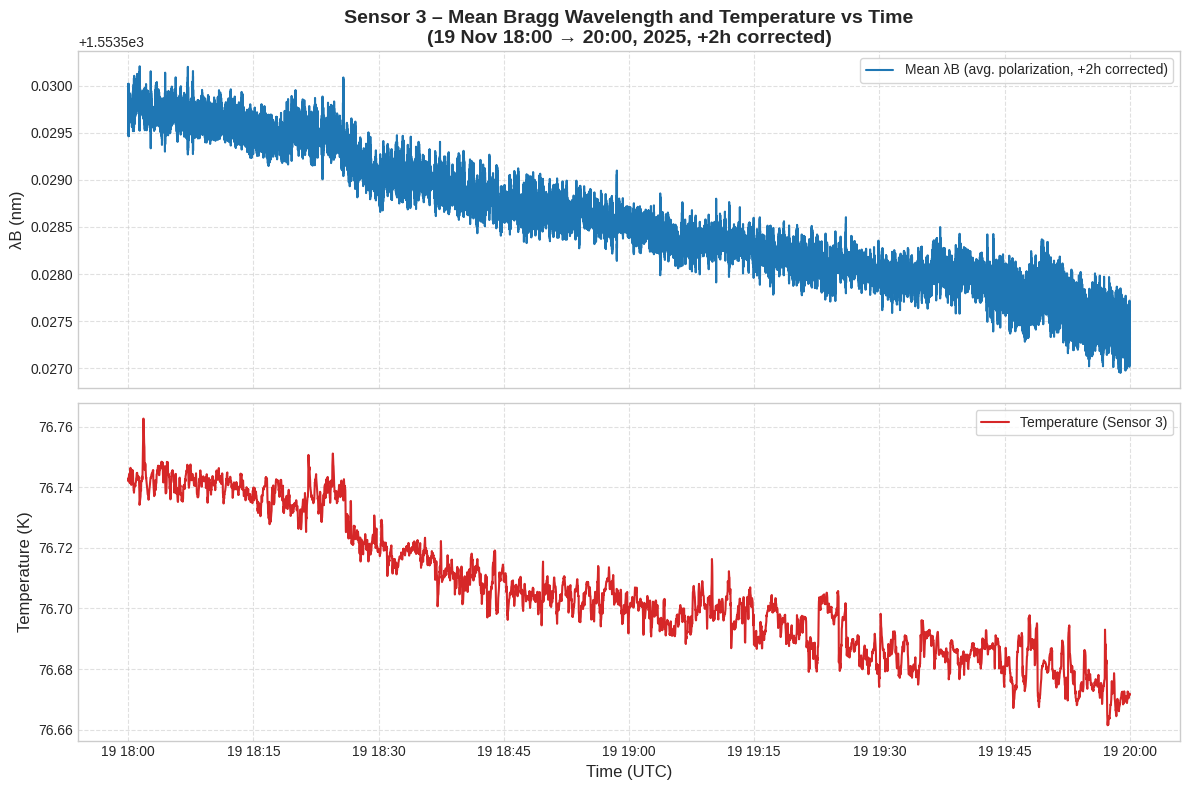

In [11]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Print intervals for confirmation ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_timestamps.min()}  →  {peak_timestamps.max()}")
print(f"Temp data:       {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("--------------------------------")

# --- Define time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 0, 0)
end_time   = datetime.datetime(2025, 11, 19, 20, 0, 0)

# --- Apply time masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average Bragg wavelength (λB) between polarizations ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot: λB and Temperature vs Time ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- λB average ---
ax1.plot(peak_t_filtered, sensor3_mean * 1e9, label="Mean λB (avg. polarization, +2h corrected)",
         color="tab:blue", linewidth=1.5)
ax1.set_ylabel("λB (nm)", fontsize=12)
ax1.set_title("Sensor 3 – Mean Bragg Wavelength and Temperature vs Time\n(19 Nov 18:00 → 20:00, 2025, +2h corrected)",
              fontsize=14, weight='bold')
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# --- Temperature ---
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temperature (Sensor 3)", color="tab:red", linewidth=1.5)
ax2.set_xlabel("Time (UTC)", fontsize=12)
ax2.set_ylabel("Temperature (K)", fontsize=12)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


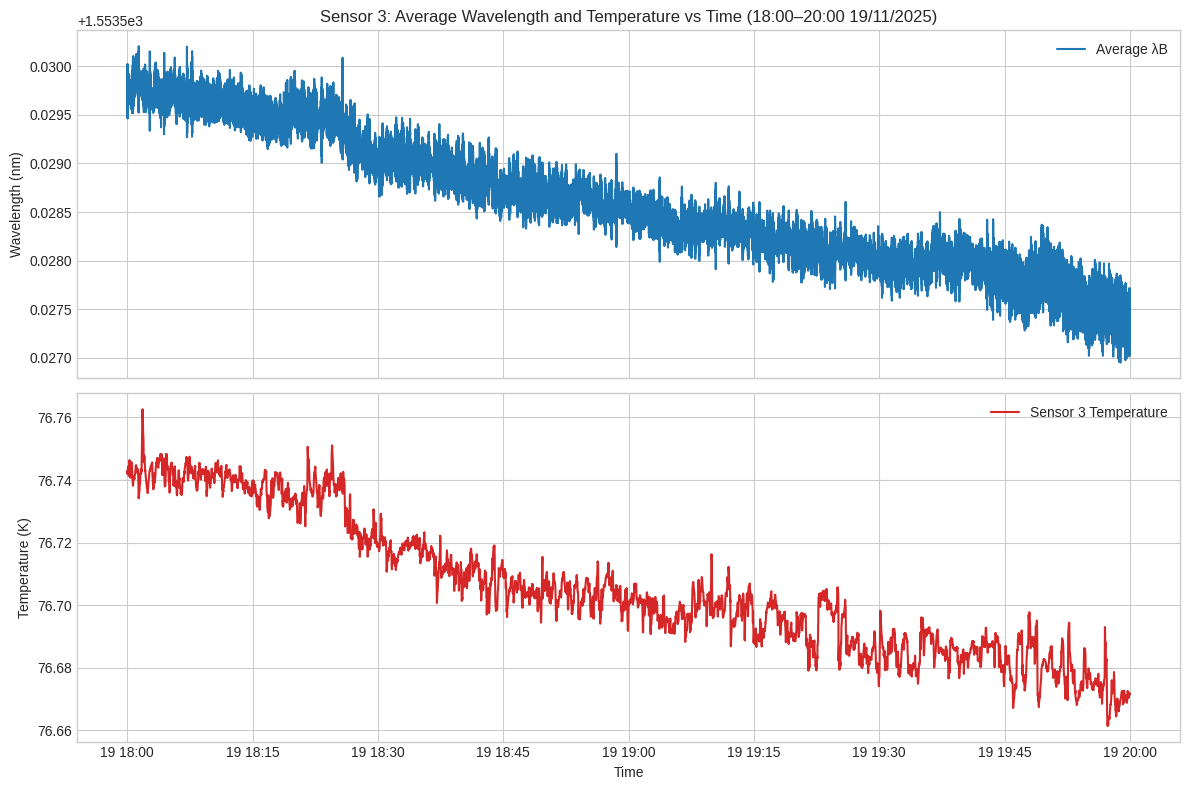

In [12]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # first polarization timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]    # polarization 1
sensor3_pol2 = peak_data["wav"][:, 1, 2]    # polarization 2

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime objects ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Define time filter ---
start_time = datetime.datetime(2025, 11, 19, 18, 0, 0)
end_time   = datetime.datetime(2025, 11, 19, 20, 0, 0)

# Apply mask to peak data
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

# Apply mask to temperature data
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot in two subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top subplot: wavelength (λB)
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="Average λB", color="tab:blue")
ax1.set_ylabel("Wavelength (nm)")
ax1.set_title("Sensor 3: Average Wavelength and Temperature vs Time (18:00–20:00 19/11/2025)")
ax1.legend()
ax1.grid(True)

# Bottom subplot: temperature
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Sensor 3 Temperature", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/vgarciap/ipykernel_4182166/2151953824.py:64: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  peak_resampled_mean = df_peak.resample("5T").mean()
/tmp/vgarciap/ipykernel_4182166/2151953824.py:65: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  peak_resampled_std  = df_peak.resample("5T").std()
/tmp/vgarciap/ipykernel_4182166/2151953824.py:67: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  temp_resampled_mean = df_temp.resample("5T").mean()
/tmp/vgarciap/ipykernel_4182166/2151953824.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  temp_resampled_std  = df_temp.resample("5T").std()
/tmp/vgarciap/ipykernel_4182166/2151953824.py:65: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  peak_resampled_std  = df_peak.resa

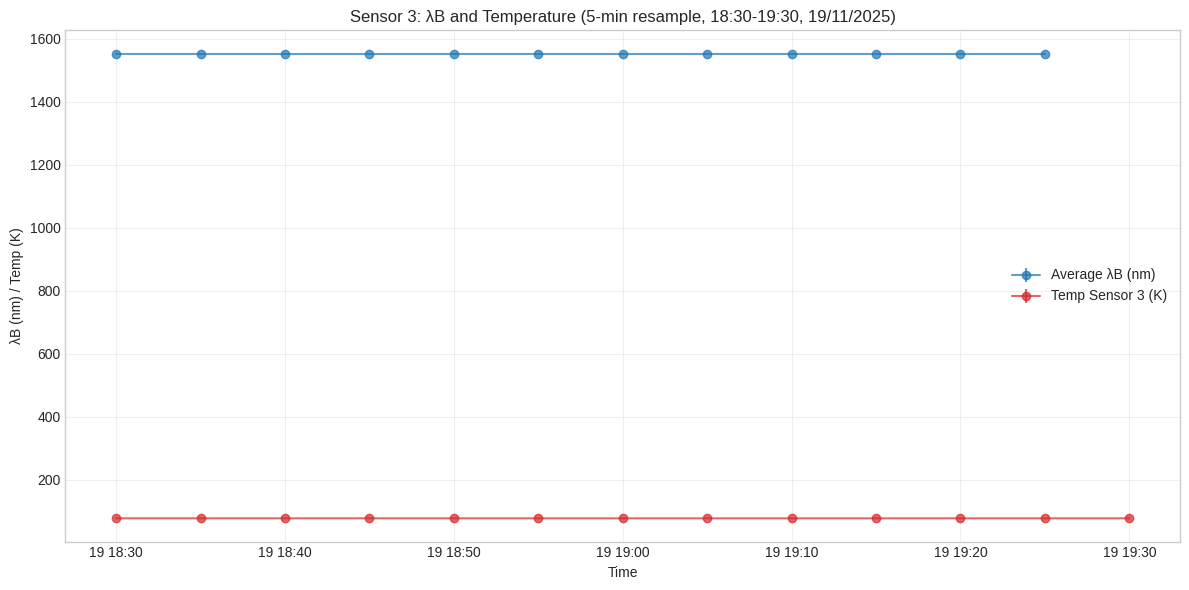

In [13]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = pd.Timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Define time filter ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

# --- Apply mask ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

# Filtered data
peak_times_f = peak_timestamps[mask_peak]
sensor3_pol1_f = sensor3_pol1[mask_peak]
sensor3_pol2_f = sensor3_pol2[mask_peak]

temp_times_f = temp_timestamps[mask_temp]
sensor3_temp_f = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_f + sensor3_pol2_f) / 2

# --- Convert to DataFrames for resampling ---
df_peak = pd.DataFrame({
    "lambdaB_nm": sensor3_mean * 1e9,
    "lambdaB_pol1_nm": sensor3_pol1_f * 1e9,
    "lambdaB_pol2_nm": sensor3_pol2_f * 1e9
}, index=peak_times_f)

df_temp = pd.DataFrame({
    "temp_K": sensor3_temp_f
}, index=temp_times_f)

# --- Resample every 5 minutes, computing mean and std ---
peak_resampled_mean = df_peak.resample("5T").mean()
peak_resampled_std  = df_peak.resample("5T").std()

temp_resampled_mean = df_temp.resample("5T").mean()
temp_resampled_std  = df_temp.resample("5T").std()

# --- Plot λB and Temperature vs Time with error bars ---
fig, ax = plt.subplots(figsize=(12,6))

# λB with std
ax.errorbar(peak_resampled_mean.index, peak_resampled_mean["lambdaB_nm"],
            yerr=peak_resampled_std["lambdaB_nm"], label="Average λB (nm)",
            color="tab:blue", fmt='-o', alpha=0.7)

# Temperature with std
ax.errorbar(temp_resampled_mean.index, temp_resampled_mean["temp_K"],
            yerr=temp_resampled_std["temp_K"], label="Temp Sensor 3 (K)",
            color="tab:red", fmt='-o', alpha=0.7)

ax.set_xlabel("Time")
ax.set_ylabel("λB (nm) / Temp (K)")
ax.set_title("Sensor 3: λB and Temperature (5-min resample, 18:30-19:30, 19/11/2025)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

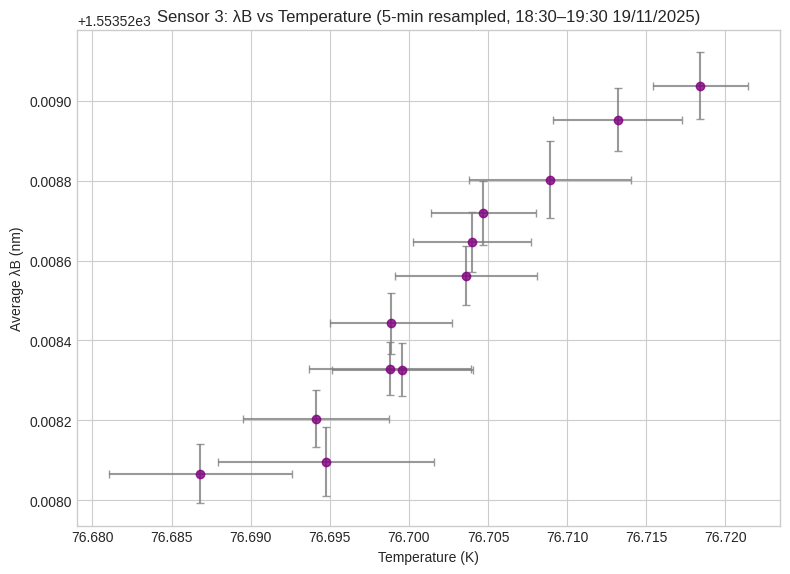

In [14]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Extract Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # take first polarization for timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Average the two polarizations ---
sensor3_lambdaB = (sensor3_pol1 + sensor3_pol2) / 2

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# Apply time masks
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor3_lambdaB[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor3_temp[mask_temp]

# --- Build DataFrames ---
df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)

# --- Resample every 5 minutes, compute mean and std ---
peak_resampled = df_peak.resample("5min").agg(["mean","std"])
temp_resampled = df_temp.resample("5min").agg(["mean","std"])

# --- Combine into single DataFrame aligned by time ---
df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()

# --- Scatter plot λB vs Temperature with error bars ---
plt.figure(figsize=(8,6))
plt.errorbar(
    df_combined["temp_K"]["mean"], 
    df_combined["lambdaB_nm"]["mean"], 
    xerr=df_combined["temp_K"]["std"], 
    yerr=df_combined["lambdaB_nm"]["std"], 
    fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
)
plt.xlabel("Temperature (K)")
plt.ylabel("Average λB (nm)")
plt.title("Sensor 3: λB vs Temperature (5-min resampled, 18:30–19:30 19/11/2025)")
plt.grid(True)
plt.tight_layout()
plt.show()

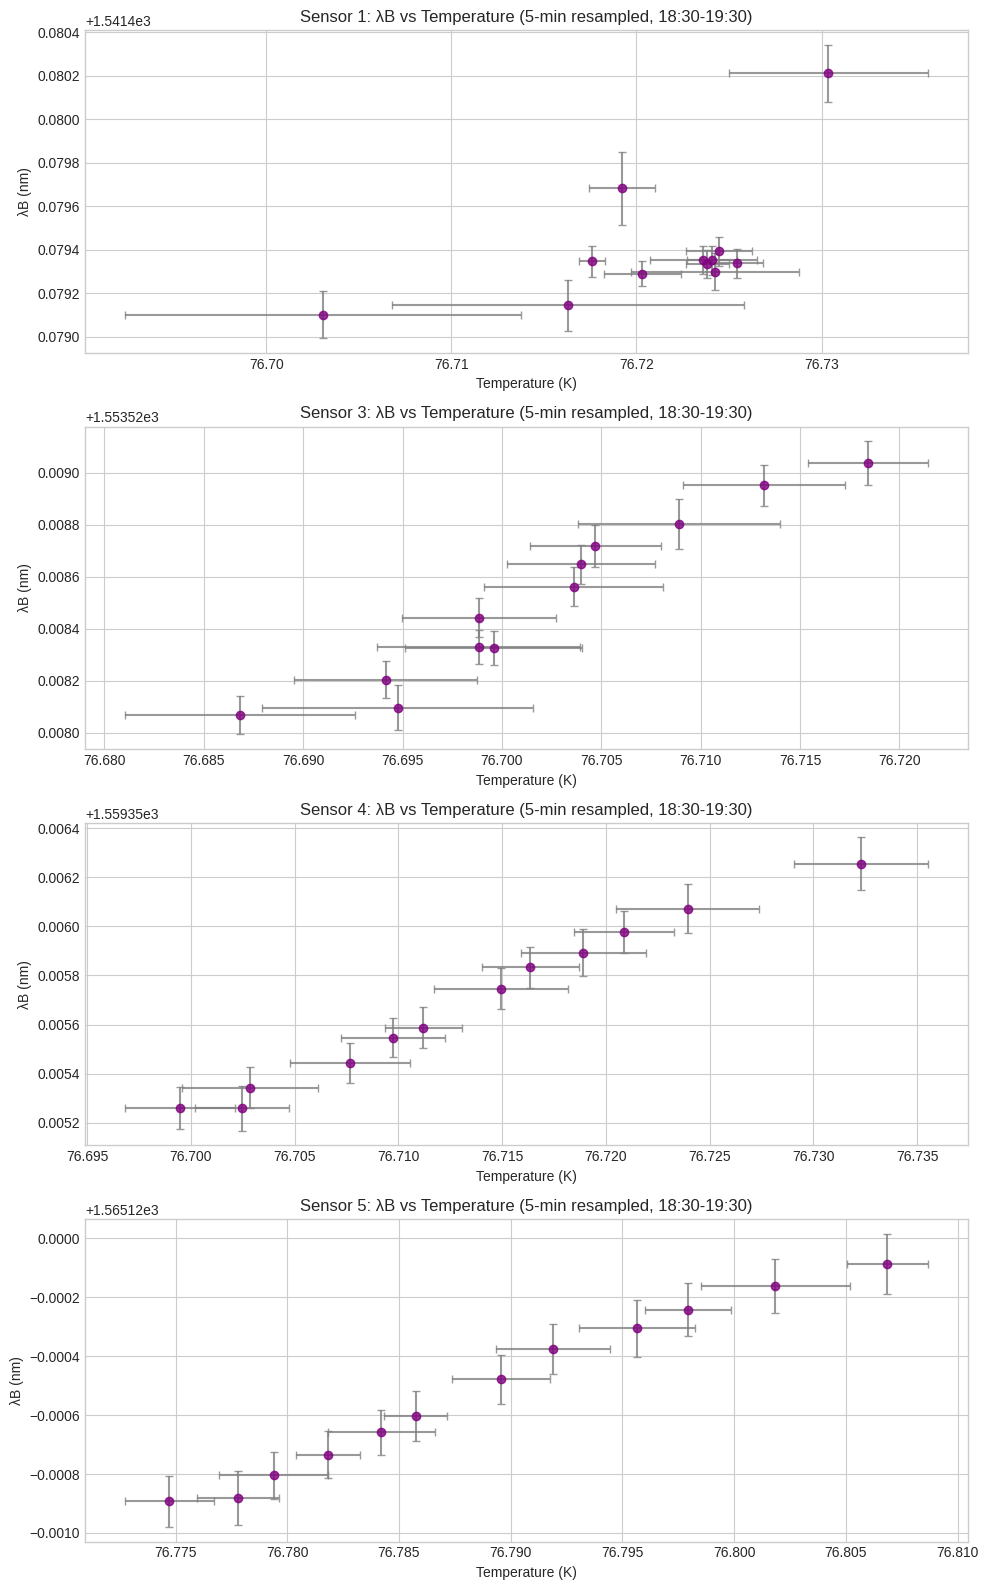

In [15]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Analyze all sensors 1, 3, 4, 5 ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=False)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # Combine resampled data
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Scatter plot λB vs Temperature with error bars ---
    axes[i].errorbar(
        df_combined["temp_K"]["mean"], 
        df_combined["lambdaB_nm"]["mean"], 
        xerr=df_combined["temp_K"]["std"], 
        yerr=df_combined["lambdaB_nm"]["std"], 
        fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
    )
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (nm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (5-min resampled, 18:30-19:30)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-19 16:09:59.167191982  →  2025-11-20 09:01:53.775902033
Temp data:       2025-11-19 16:04:25  →  2025-11-19 23:55:40
--------------------------------


===== SENSOR 1 =====
λB range: 1541.479–1541.481 nm
T range:  76.68–76.74 K
Fit data points: 30
x mean ± std: 1541.479 ± 0.000 nm
y mean ± std: 76.72 ± 0.01 K
Slope: 0.81 mK/pm
Intercept: -1172.11 K

===== SENSOR 3 =====
λB range: 1553.528–1553.529 nm
T range:  76.67–76.73 K
Fit data points: 30
x mean ± std: 1553.529 ± 0.000 nm
y mean ± std: 76.70 ± 0.01 K
Slope: 30.65 mK/pm
Intercept: -47537.51 K

===== SENSOR 4 =====
λB range: 1559.355–1559.357 nm
T range:  76.69–76.74 K
Fit data points: 30
x mean ± std: 1559.356 ± 0.000 nm
y mean ± std: 76.71 ± 0.01 K
Slope: 31.25 mK/pm
Intercept: -48650.18 K

===== SENSOR 5 =====
λB range: 1565.119–1565.120 nm
T range:  76.77–76.81 K
Fit data points: 30
x mean ± std: 1565.119 ± 0.000 nm
y mean ± std: 76.79 ± 0.01 K
Slope: 34.67 mK/pm
Intercept: 

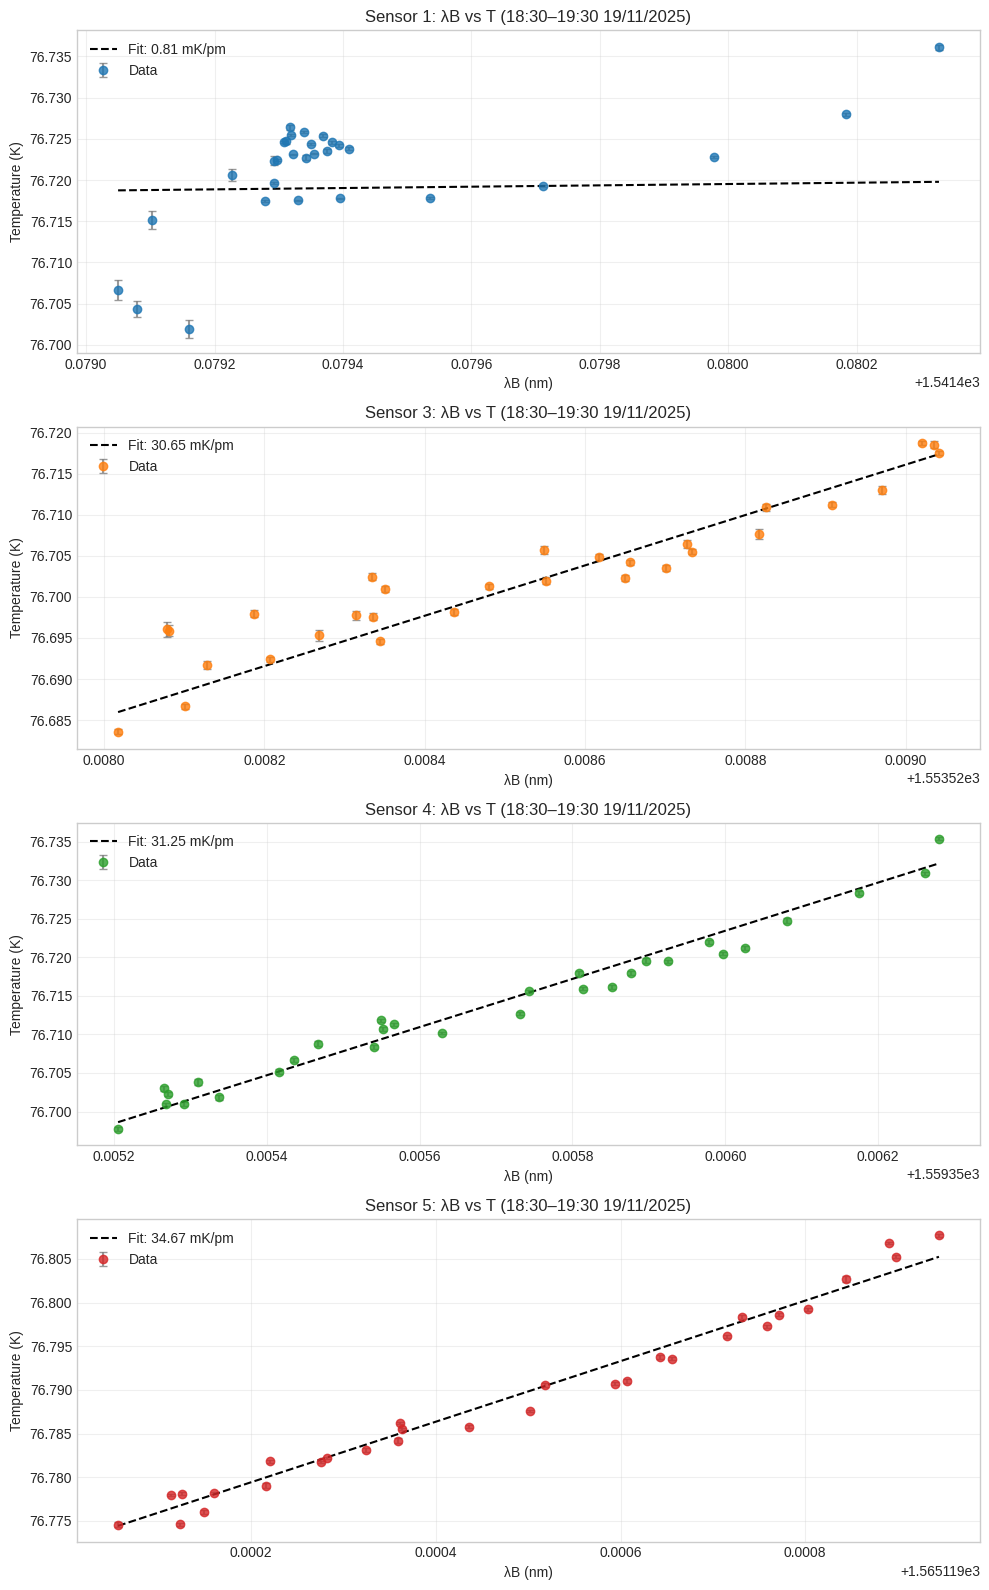

In [16]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # Average λB from both polarizations
    lambdaB_m = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2  # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_filtered = lambdaB_nm[mask_peak]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.3f}–{lambdaB_filtered.max():.3f} nm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 2 minutes → mean & std
    peak_resampled = df_peak.resample("2min").agg(['mean','std'])
    temp_resampled = df_temp.resample("2min").agg(['mean','std'])
    
    # Standard error of the mean
    peak_resampled['lambdaB_nm','se'] = peak_resampled['lambdaB_nm','std'] / np.sqrt(df_peak.resample("2min").count()['lambdaB_nm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("2min").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit (x=λB in nm, y=T in K) ---
    x = df_combined['lambdaB_nm','mean'].values
    y = df_combined['temp_K','mean'].values
    yerr = df_combined['temp_K','se'].values

    print(f"Fit data points: {len(x)}")
    print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} nm")
    print(f"y mean ± std: {np.mean(y):.2f} ± {np.std(y):.2f} K")
    
    w = 1 / yerr**2
    slope, intercept = np.polyfit(x, y, 1, w=w)
    
    # Convert slope to mK/pm (numerically same as K/nm)
    slope_mK_pm = slope * 1.0  # numerically the same
    print(f"Slope: {slope_mK_pm:.2f} mK/pm")
    print(f"Intercept: {intercept:.2f} K")
    
    # --- Plot scatter with error bars and fit ---
    axes[i].errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label="Data")
    
    # Fit line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    axes[i].plot(x_fit, y_fit, 'k--', label=f"Fit: {slope_mK_pm:.2f} mK/pm")
    
    axes[i].set_xlabel("λB (nm)")
    axes[i].set_ylabel("Temperature (K)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs T (18:30–19:30 19/11/2025)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

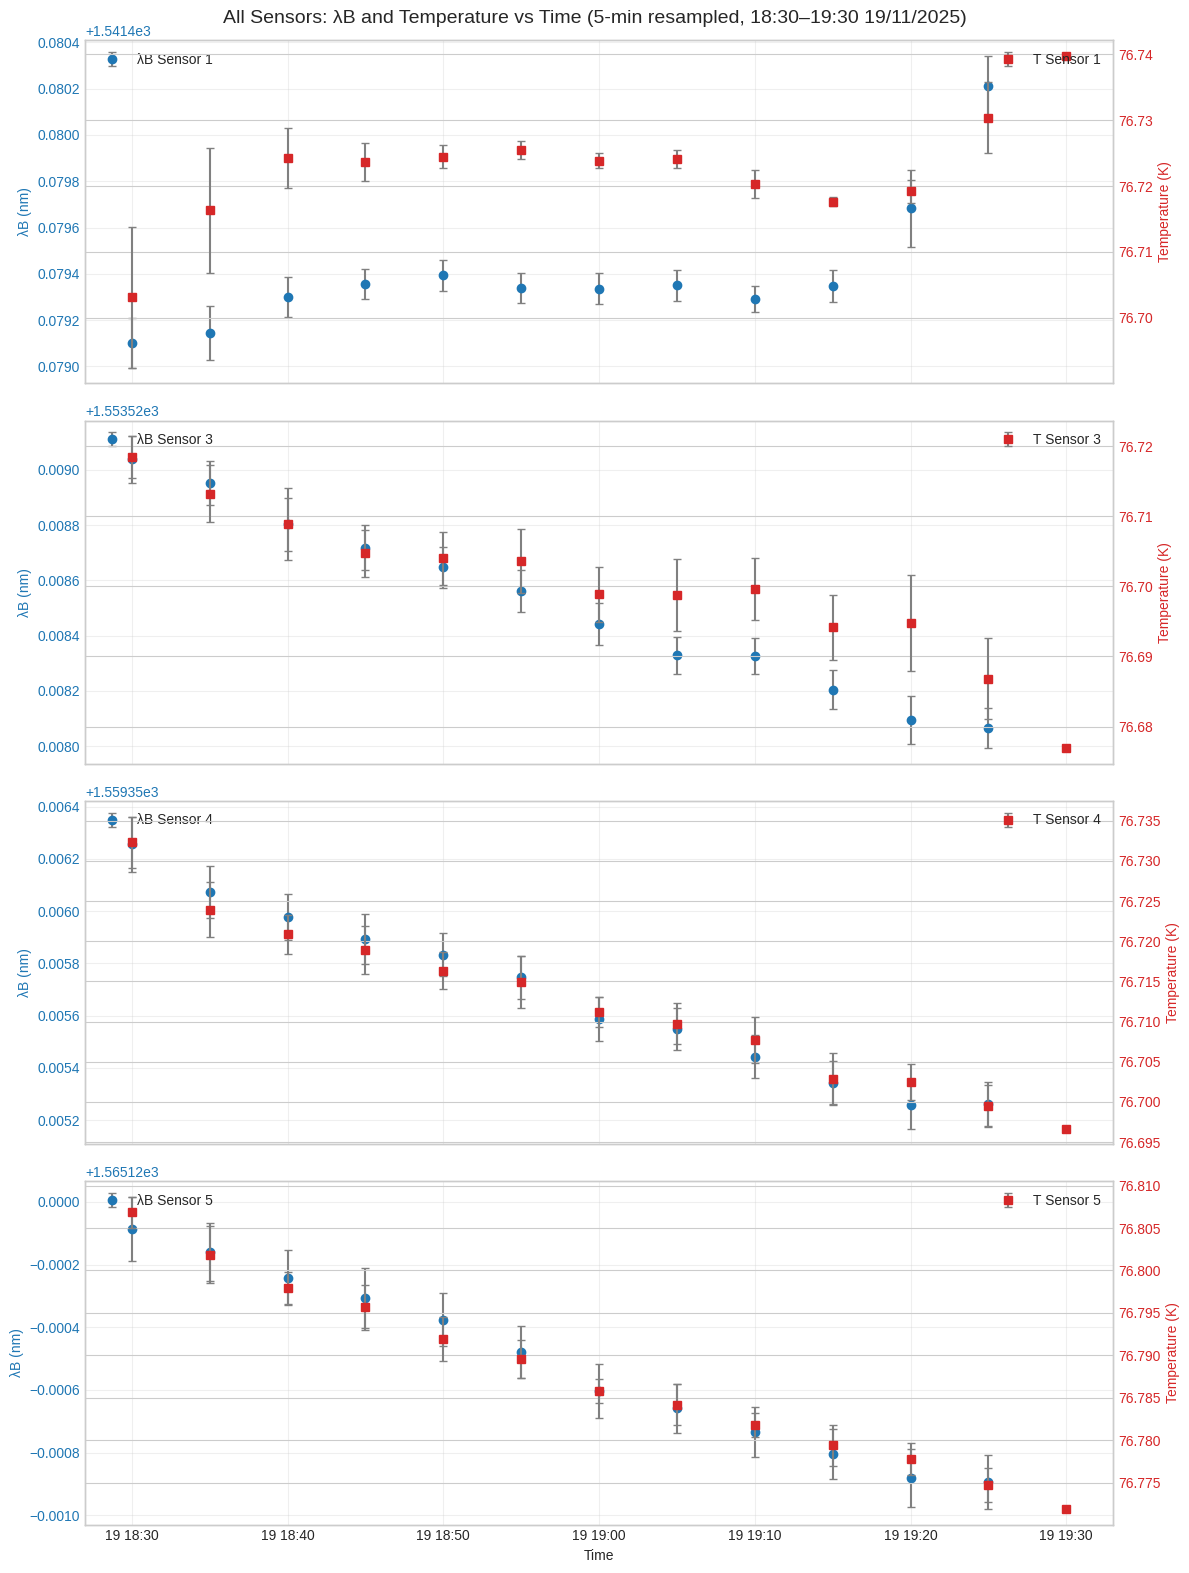

In [17]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift


# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # --- Plot λB with error bars ---
    axes[i].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                     yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color="tab:blue",
                     ecolor='gray', capsize=3, label=f"λB Sensor {sensor+1}")
    axes[i].set_ylabel("λB (nm)", color="tab:blue")
    axes[i].tick_params(axis='y', labelcolor="tab:blue")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper left')
    
    # --- Create secondary y-axis for temperature ---
    ax2 = axes[i].twinx()
    ax2.errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                 yerr=temp_resampled["temp_K"]["std"], fmt='s', color="tab:red",
                 ecolor='gray', capsize=3, label=f"T Sensor {sensor+1}")
    ax2.set_ylabel("Temperature (K)", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")
    ax2.legend(loc='upper right')

axes[-1].set_xlabel("Time")
fig.suptitle("All Sensors: λB and Temperature vs Time (5-min resampled, 18:30–19:30 19/11/2025)", fontsize=14)
plt.tight_layout()
plt.show()

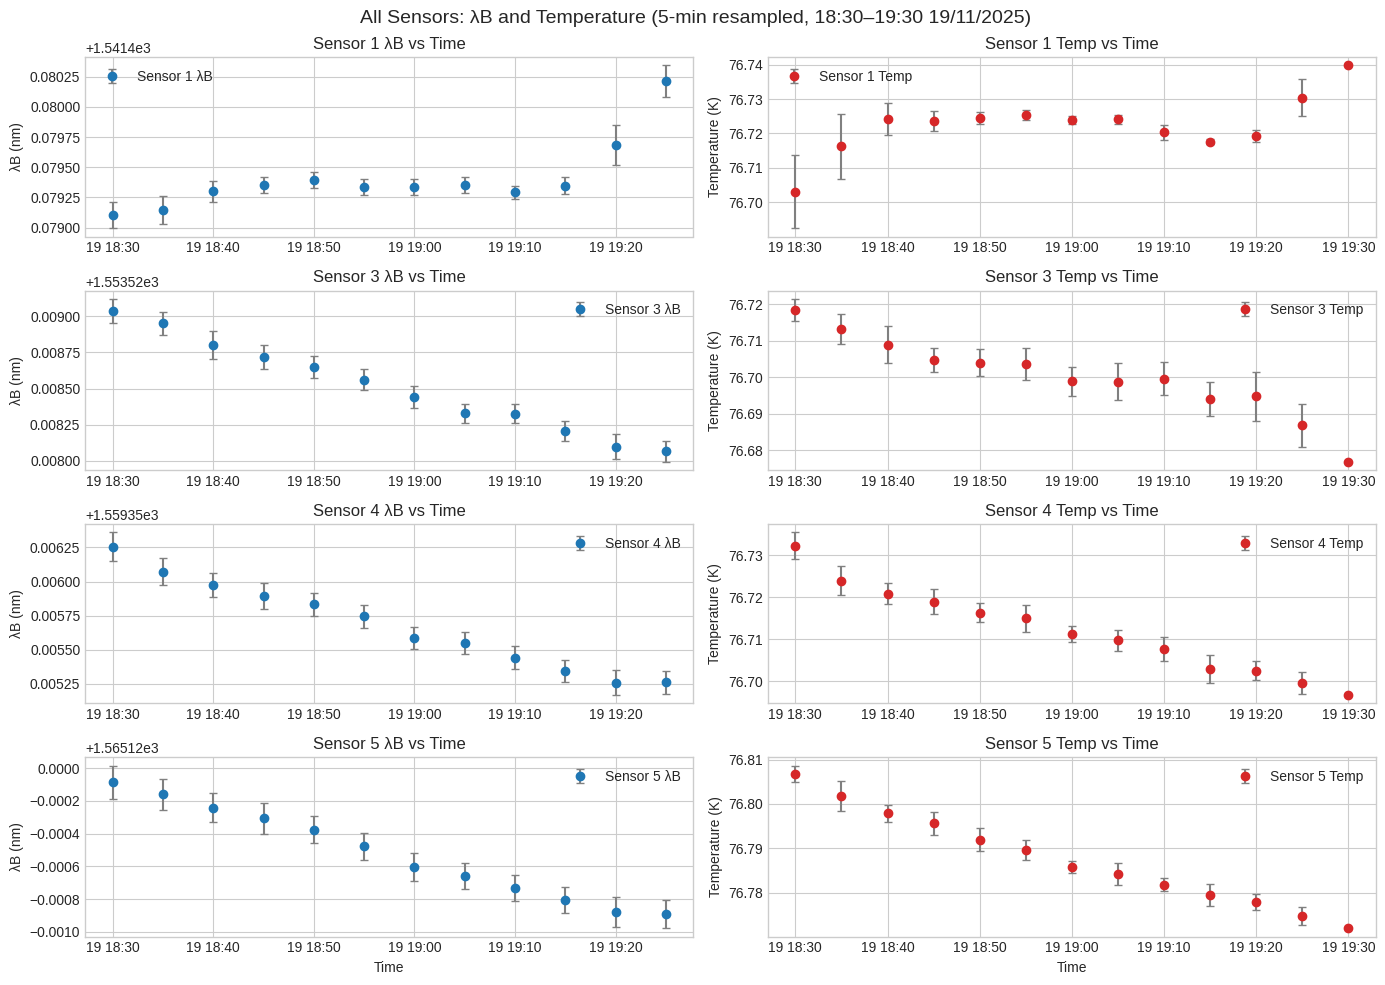

In [18]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot (0-based, skipping sensor 2) ---
sensor_indices = [0, 2, 3, 4]  # sensors 1,3,4,5

# --- Convert times to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')
# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

# --- Create figure ---
fig, axes = plt.subplots(len(sensor_indices), 2, figsize=(14, 10), sharex=False)
fig.subplots_adjust(hspace=0.4)

for i, sensor_idx in enumerate(sensor_indices):
    # Extract λB and average over polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor_idx] + peak_data["wav"][:, 1, sensor_idx]) / 2
    mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])

    # Extract temperature
    sensor_temp = temp_data["temp"][:, sensor_idx]
    mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
    df_temp = pd.DataFrame({"temp_K": sensor_temp[mask_temp]}, index=temp_timestamps[mask_temp])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])

    # --- Plot λB vs Time ---
    axes[i, 0].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                        yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color='tab:blue',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} λB")
    axes[i, 0].set_ylabel("λB (nm)")
    axes[i, 0].set_title(f"Sensor {sensor_idx+1} λB vs Time")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # --- Plot Temp vs Time ---
    axes[i, 1].errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                        yerr=temp_resampled["temp_K"]["std"], fmt='o', color='tab:red',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} Temp")
    axes[i, 1].set_ylabel("Temperature (K)")
    axes[i, 1].set_title(f"Sensor {sensor_idx+1} Temp vs Time")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

# Common x-labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

fig.suptitle("All Sensors: λB and Temperature (5-min resampled, 18:30–19:30 19/11/2025)", fontsize=14)
plt.tight_layout()
plt.show()

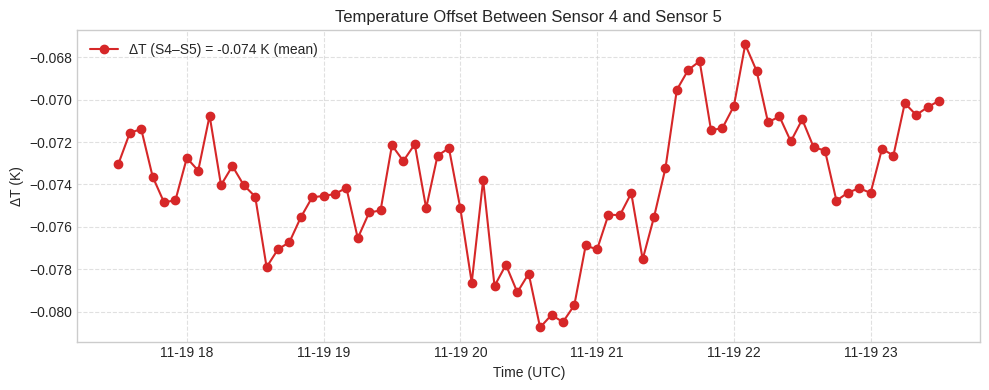

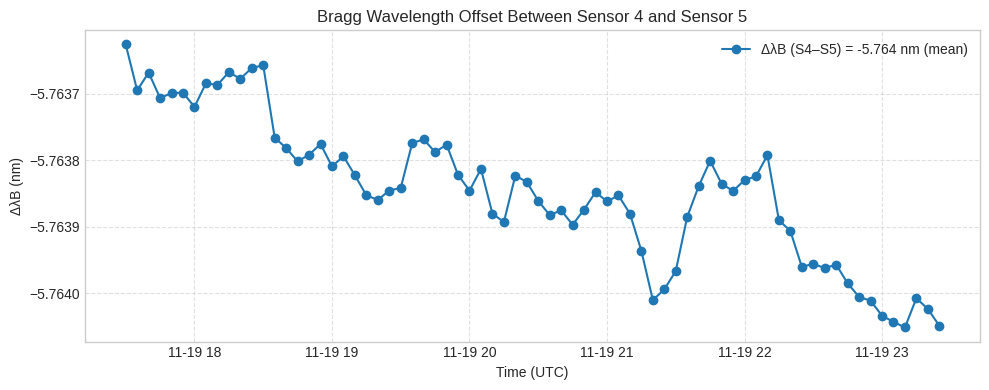

In [48]:
# --- Compare stability between Sensor 4 and Sensor 5 ---
# Replicating the methodology from ROOT_DEWAR_07_11.ipynb celda 19

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import uproot

# --- Load data again (if not in memory) ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Time conversion and correction ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Sensors 4 and 5 (indices 3 and 4 in 0-based) ---
s4, s5 = 3, 4

# --- Time window ---
start_time = datetime.datetime(2025, 11, 19, 17, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 23, 30, 0)

# --- λB (average over polarizations) ---
lambdaB_4 = (peak_data["wav"][:, 0, s4] + peak_data["wav"][:, 1, s4]) / 2
lambdaB_5 = (peak_data["wav"][:, 0, s5] + peak_data["wav"][:, 1, s5]) / 2

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
df_peak4 = pd.DataFrame({"lambdaB_nm": lambdaB_4[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
df_peak5 = pd.DataFrame({"lambdaB_nm": lambdaB_5[mask_peak]*1e9}, index=peak_timestamps[mask_peak])

# --- Temperature ---
temp_4 = temp_data["temp"][:, s4]
temp_5 = temp_data["temp"][:, s5]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
df_temp4 = pd.DataFrame({"temp_K": temp_4[mask_temp]}, index=temp_timestamps[mask_temp])
df_temp5 = pd.DataFrame({"temp_K": temp_5[mask_temp]}, index=temp_timestamps[mask_temp])

# --- Resample to 5-minute intervals ---
peak4_res = df_peak4.resample("5min").mean()
peak5_res = df_peak5.resample("5min").mean()
temp4_res = df_temp4.resample("5min").mean()
temp5_res = df_temp5.resample("5min").mean()

# --- Compute offsets (Sensor 4 - Sensor 5) ---
temp_offset = temp4_res["temp_K"] - temp5_res["temp_K"]
lambdaB_offset = peak4_res["lambdaB_nm"] - peak5_res["lambdaB_nm"]

# --- Calculate mean offsets for legend ---
mean_temp_offset = temp_offset.mean()
mean_lambdaB_offset = lambdaB_offset.mean()

# --- Plot Temperature Offset ---
plt.figure(figsize=(10,4))
plt.plot(temp_offset.index, temp_offset, marker='o', color='tab:red', label=f"ΔT (S4–S5) = {mean_temp_offset:.3f} K (mean)")
plt.title("Temperature Offset Between Sensor 4 and Sensor 5")
plt.xlabel("Time (UTC)")
plt.ylabel("ΔT (K)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Bragg Wavelength Offset ---
plt.figure(figsize=(10,4))
plt.plot(lambdaB_offset.index, lambdaB_offset, marker='o', color='tab:blue', label=f"ΔλB (S4–S5) = {mean_lambdaB_offset:.3f} nm (mean)")
plt.title("Bragg Wavelength Offset Between Sensor 4 and Sensor 5")
plt.xlabel("Time (UTC)")
plt.ylabel("ΔλB (nm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


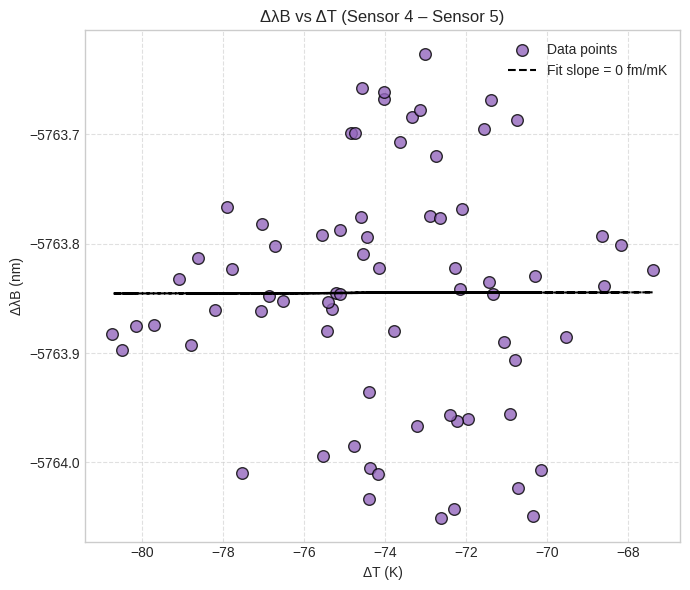

In [49]:
# --- ΔλB vs ΔT (Offset Correlation between Sensor 4 and 5) ---

# Ensure matching time index (they should already align via resampling)
df_offset = pd.concat([temp_offset, lambdaB_offset], axis=1).dropna()
df_offset.columns = ["delta_T", "delta_lambdaB"]

# --- Linear fit ---
x = 1e3*df_offset["delta_T"].values
y = 1e3*df_offset["delta_lambdaB"].values
if len(x) > 2:
    slope, intercept = np.polyfit(x, y, 1)
else:
    slope, intercept = np.nan, np.nan

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(x, y, color='tab:purple', s=70, alpha=0.8, edgecolor='k', label="Data points")
plt.plot(x, slope*x + intercept, 'k--', label=f"Fit slope = {1e3*slope:.0f} fm/mK")

plt.title("ΔλB vs ΔT (Sensor 4 – Sensor 5)")
plt.xlabel("ΔT (K)")
plt.ylabel("ΔλB (nm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


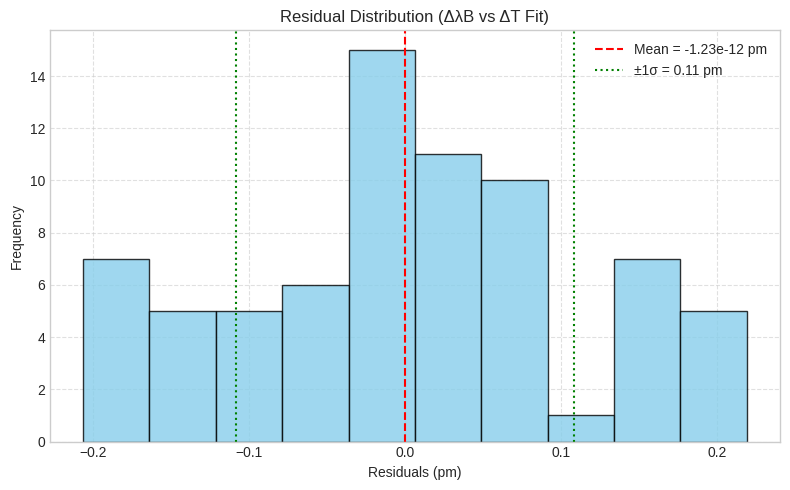

Residuals mean: -1.225e-12 pm
Residuals std:  0.108 pm


In [50]:
# --- Residual Analysis: Histogram of Fit Residuals ---

# Compute residuals (in pm)
y_fit = slope * x + intercept
residuals = y - y_fit  # in same units as y (pm)
res_mean = np.mean(residuals)
res_std = np.std(residuals)

# --- Plot histogram ---
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=10, color='skyblue', edgecolor='k', alpha=0.8)
plt.axvline(res_mean, color='r', linestyle='--', label=f"Mean = {res_mean:.2e} pm")
plt.axvline(res_mean + res_std, color='g', linestyle=':', label=f"±1σ = {res_std:.2f} pm")
plt.axvline(res_mean - res_std, color='g', linestyle=':')

plt.title("Residual Distribution (ΔλB vs ΔT Fit)")
plt.xlabel("Residuals (pm)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Print numerical results
print(f"Residuals mean: {res_mean:.3e} pm")
print(f"Residuals std:  {res_std:.3f} pm")


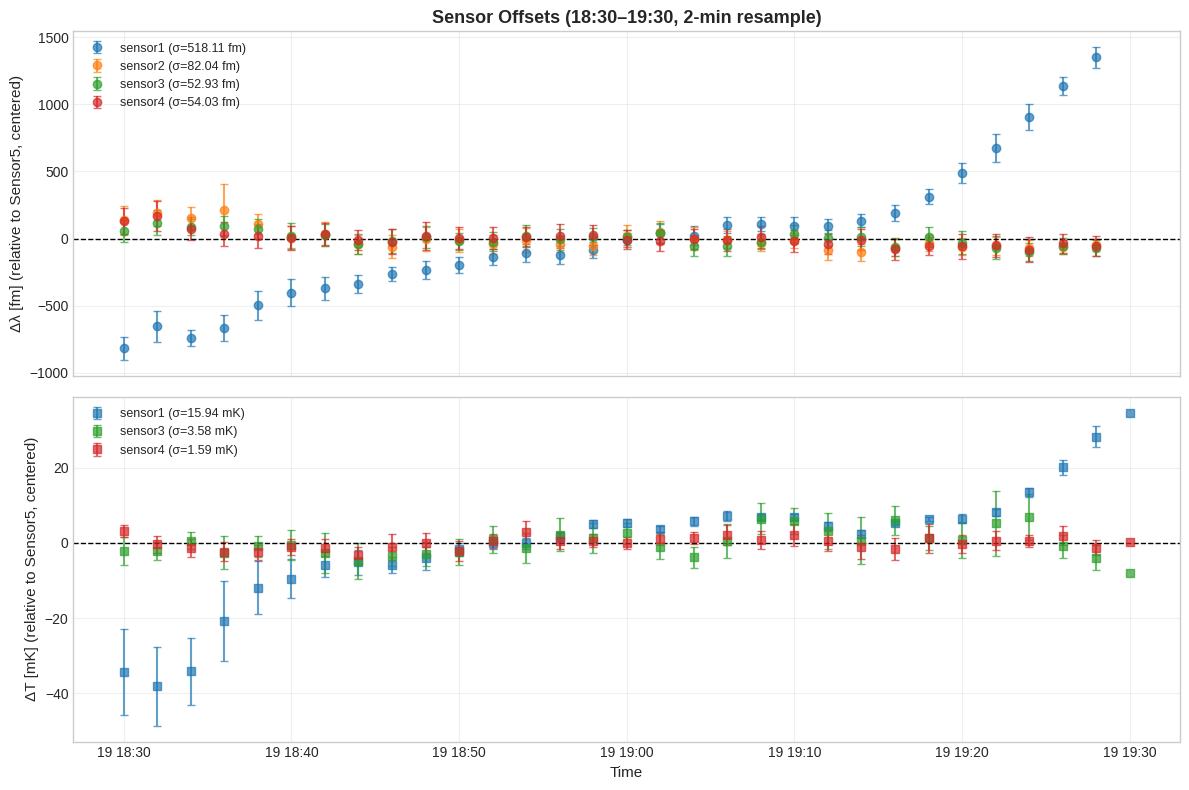

In [51]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices (peaks: sensors1,2,3,4,5; temp: sensors1,3,4,5) ---
sensors_peak = [0, 1, 2, 3, 4]
sensors_temp = [0, 2, 3, 4]

# --- Extract λB averaged over polarizations ---
lambdaB_pol1 = peak_data["wav"][:, 0, sensors_peak]
lambdaB_pol2 = peak_data["wav"][:, 1, sensors_peak]
sensor_lambdaB = (lambdaB_pol1 + lambdaB_pol2) / 2

# --- Extract temperatures ---
sensor_temp = temp_data["temp"]

# --- Convert timestamps ---
peak_times = peak_data["t"][:, 0]
temp_times = temp_data["t"]

peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift


# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 19, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor_lambdaB[mask_peak, :]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor_temp[mask_temp, :]

# --- Build DataFrames ---
df_peak = pd.DataFrame(lambdaB_filtered * 1e15,  # convertir nm -> fm
                       columns=[f"sensor{i+1}" for i in range(lambdaB_filtered.shape[1])], 
                       index=peak_t_filtered)
df_temp = pd.DataFrame(temp_filtered[:, sensors_temp] * 1e3,  # K -> mK
                       columns=[f"sensor{i+1}" for i in sensors_temp], 
                       index=temp_t_filtered)

# --- Resample cada 2 minutos ---
peak_resampled = df_peak.resample("2min").agg(["mean","std"])
temp_resampled = df_temp.resample("2min").agg(["mean","std"])

# --- Compute offsets relative to Sensor5 (index 4) y centrar ---
lambda_mean = peak_resampled.xs('mean', axis=1, level=1)
lambda_offsets = lambda_mean.subtract(lambda_mean["sensor5"], axis=0)
lambda_offsets_centered = lambda_offsets - lambda_offsets.mean()

temp_mean = temp_resampled.xs('mean', axis=1, level=1)
temp_offsets = temp_mean.subtract(temp_mean["sensor5"], axis=0)
temp_offsets_centered = temp_offsets - temp_offsets.mean()

# --- Extract std for error bars ---
lambda_std = peak_resampled.xs('std', axis=1, level=1)
temp_std = temp_resampled.xs('std', axis=1, level=1)

# --- Compute total std along time for legend ---
lambda_std_total = lambda_offsets_centered.std()
temp_std_total = temp_offsets_centered.std()

# --- Plot ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]  # Sensor2 extra included for peaks

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8), sharex=True)

# Top subplot: λB offsets (scatter + std)
for i, col in enumerate(lambda_offsets_centered.columns):
    if col == "sensor5":
        continue  # Skip reference sensor
    ax1.errorbar(lambda_offsets_centered.index, lambda_offsets_centered[col], 
                 yerr=lambda_std[col], label=f"{col} (σ={lambda_std_total[col]:.2f} fm)",
                 fmt='o', color=colors[i], alpha=0.7, capsize=3)

ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_ylabel("Δλ [fm] (relative to Sensor5, centered)", fontsize=11)
ax1.set_title("Sensor Offsets (18:30–19:30, 2-min resample)", fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# Bottom subplot: Temperature offsets (scatter + std)
for i, col in enumerate(temp_offsets_centered.columns):
    if col == "sensor5":
        continue
    idx_map = {"sensor1":0, "sensor3":2, "sensor4":3}
    ax2.errorbar(temp_offsets_centered.index, temp_offsets_centered[col],
                 yerr=temp_std[col], label=f"{col} (σ={temp_std_total[col]:.2f} mK)",
                 fmt='s', color=colors[idx_map[col]], alpha=0.7, capsize=3)

ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("Time", fontsize=11)
ax2.set_ylabel("ΔT [mK] (relative to Sensor5, centered)", fontsize=11)
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Total de bines disponibles: 4
Índices de tiempo: [Timestamp('2025-11-19 18:20:00'), Timestamp('2025-11-19 18:40:00'), Timestamp('2025-11-19 19:00:00'), Timestamp('2025-11-19 19:20:00')]
Bines seleccionados: [Timestamp('2025-11-19 18:20:00'), Timestamp('2025-11-19 19:00:00'), Timestamp('2025-11-19 19:20:00')]


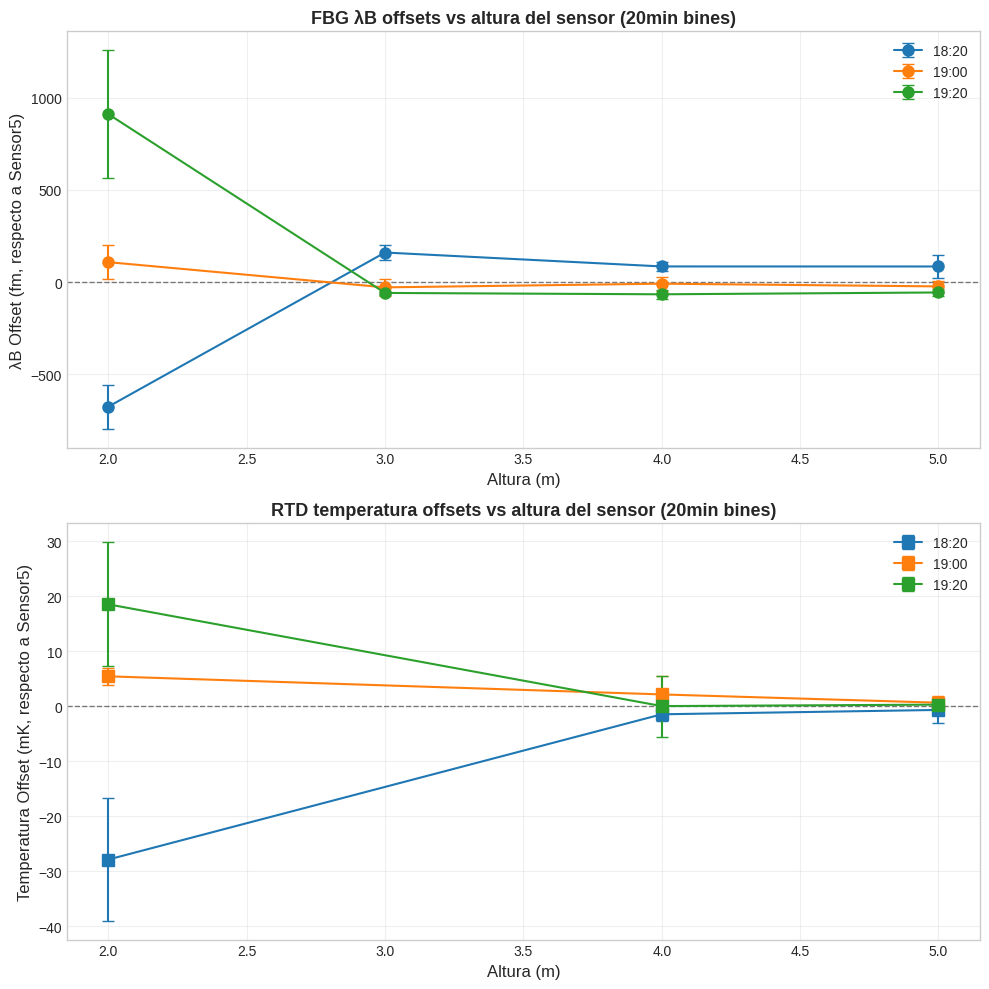

In [52]:
# --- Configuración de bines y alturas ---
bin_size = "20min"

# --- Calcular medias y desviaciones estándar por bin ---
lambda_bin_mean = lambda_offsets_centered.resample(bin_size).mean()
lambda_bin_std  = lambda_offsets_centered.resample(bin_size).std()

temp_bin_mean = temp_offsets_centered.resample(bin_size).mean()
temp_bin_std  = temp_offsets_centered.resample(bin_size).std()

print(f"Total de bines disponibles: {len(lambda_bin_mean)}")
print(f"Índices de tiempo: {lambda_bin_mean.index.tolist()}")

# --- Alturas de sensores (m) ---
sensor_heights_fbg = {
    "sensor1": 2,
    "sensor2": 3,
    "sensor3": 4,
    "sensor4": 5,
    "sensor5": 6
}

sensor_heights_temp = {
    "sensor1": 2,
    "sensor3": 4,
    "sensor4": 5,
    "sensor5": 6
}

# --- Seleccionar bines disponibles (máximo 3) ---
n_bins = len(lambda_bin_mean)
if n_bins >= 3:
    # Tomar primero, medio y último
    bin_indices = [0, n_bins//2, n_bins-1]
else:
    # Tomar todos los disponibles
    bin_indices = list(range(n_bins))

selected_bins = lambda_bin_mean.index[bin_indices]
print(f"Bines seleccionados: {selected_bins.tolist()}")

# --- Plot: Offsets vs Altura ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# --- λB offsets vs altura ---
for t in selected_bins:
    # Preparar datos para este bin temporal
    sensors_to_plot = [s for s in lambda_bin_mean.columns if s in sensor_heights_fbg and s != "sensor5"]
    heights = [sensor_heights_fbg[s] for s in sensors_to_plot]
    offsets = [lambda_bin_mean.loc[t, s] for s in sensors_to_plot]
    errors = [lambda_bin_std.loc[t, s] for s in sensors_to_plot]
    
    label_time = t.strftime("%H:%M")
    # Corregido: altura en X, offset en Y
    ax1.errorbar(heights, offsets, yerr=errors, fmt='o-', capsize=4, label=f"{label_time}", markersize=8)

ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel("Altura (m)", fontsize=12)
ax1.set_ylabel("λB Offset (fm, respecto a Sensor5)", fontsize=12)
ax1.set_title(f"FBG λB offsets vs altura del sensor ({bin_size} bines)", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# --- Temperatura offsets vs altura ---
for t in selected_bins:
    # Preparar datos para este bin temporal
    sensors_to_plot = [s for s in temp_bin_mean.columns if s in sensor_heights_temp and s != "sensor5"]
    heights = [sensor_heights_temp[s] for s in sensors_to_plot]
    offsets = [temp_bin_mean.loc[t, s] for s in sensors_to_plot]
    errors = [temp_bin_std.loc[t, s] for s in sensors_to_plot]
    
    label_time = t.strftime("%H:%M")
    # Corregido: altura en X, offset en Y
    ax2.errorbar(heights, offsets, yerr=errors, fmt='s-', capsize=4, label=f"{label_time}", markersize=8)

ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel("Altura (m)", fontsize=12)
ax2.set_ylabel("Temperatura Offset (mK, respecto a Sensor5)", fontsize=12)
ax2.set_title(f"RTD temperatura offsets vs altura del sensor ({bin_size} bines)", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


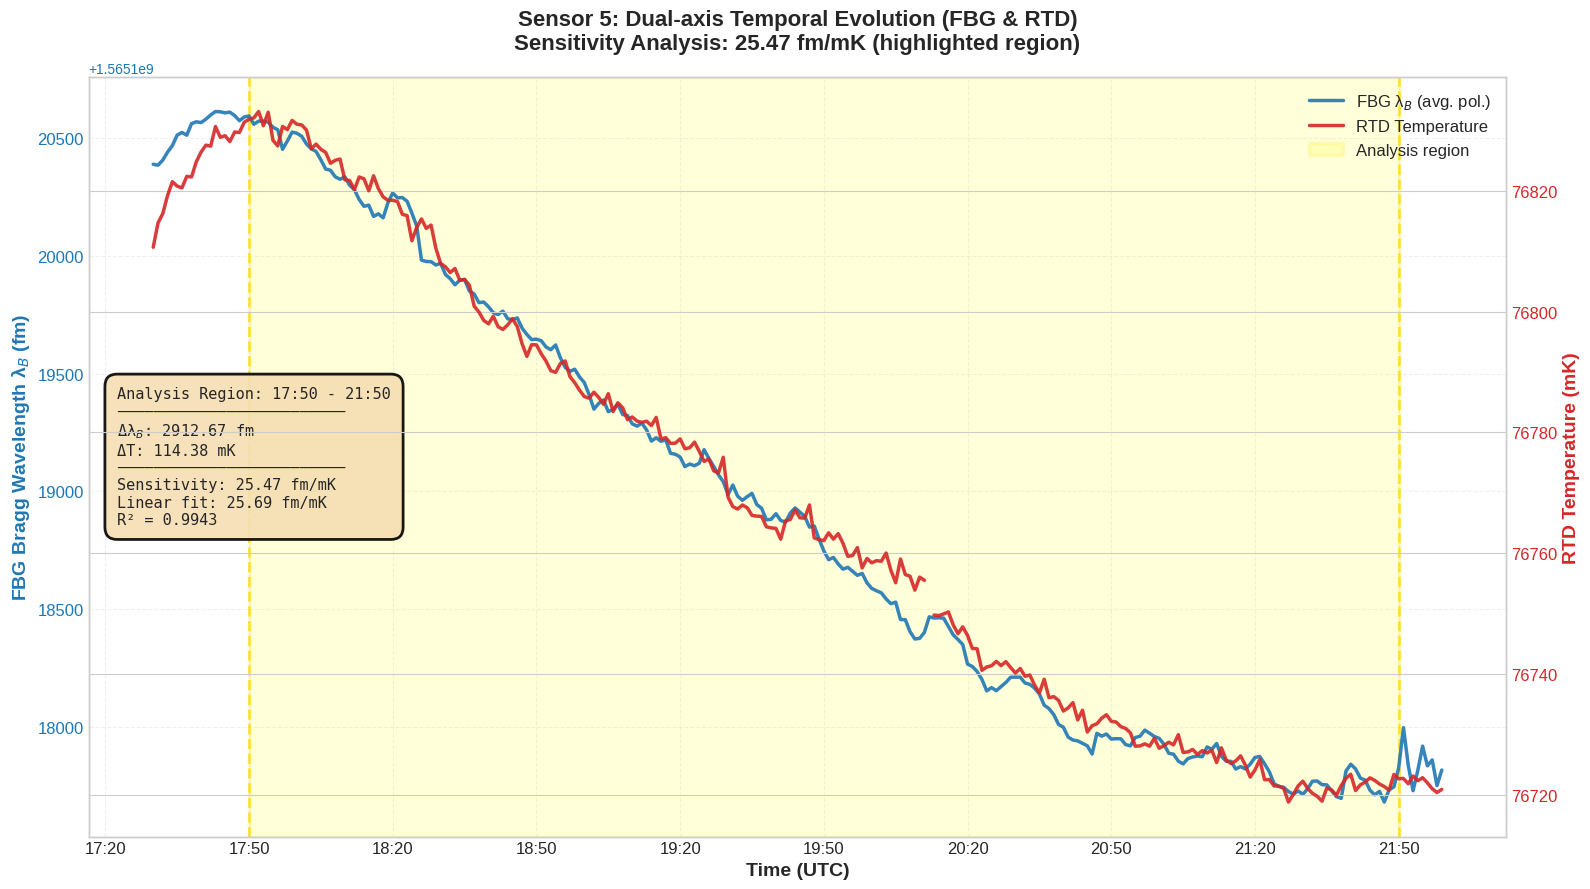

SENSOR 5 - DUAL-AXIS TEMPORAL ANALYSIS
Time window:      2025-11-19 17:30 to 22:00 UTC
Bin size:         1min
Data points:      270

──────────────────────────────────────────────────────────────────────
FULL DATASET STATISTICS
──────────────────────────────────────────────────────────────────────
FBG λ_B:
  • Mean:         1565118955.90 fm
  • Std Dev:      993.10 fm
  • Range:        1565117681.17 - 1565120612.97 fm

RTD Temperature:
  • Mean:         76768.97 mK
  • Std Dev:      38.02 mK
  • Range:        76718.79 - 76833.16 mK

SENSITIVITY ANALYSIS (HIGHLIGHTED REGION)
Region:           17:50 - 21:50 UTC
Duration:         240 minutes
Points in region: 241

Variations:
  • Δλ_B:         2912.67 fm
  • ΔT:           114.38 mK

Sensitivity:
  • Δλ/ΔT:        25.47 fm/mK
  • Linear fit:   25.69 fm/mK
  • R²:           0.9943


In [59]:
# ========================================================================
# Temporal Evolution of Sensor 5 (FBG and RTD) - Dual-axis plot
# Time window: 17:30 - 22:00 UTC
# ========================================================================

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import datetime
from matplotlib.dates import DateFormatter, MinuteLocator

# --- Load ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 5 index (0-based indexing) ---
sensor5_idx = 4

# --- Extract Sensor 5 data ---
# FBG: Average over polarizations
lambdaB_pol1_s5 = peak_data["wav"][:, 0, sensor5_idx]
lambdaB_pol2_s5 = peak_data["wav"][:, 1, sensor5_idx]
lambdaB_s5 = (lambdaB_pol1_s5 + lambdaB_pol2_s5) / 2.0  # Polarization average

# RTD: Temperature
temp_s5 = temp_data["temp"][:, sensor5_idx]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- Apply +2 hour correction to FBG timestamps ---
peak_times = peak_times + datetime.timedelta(hours=2)

# --- Define time window ---
start_time = datetime.datetime(2025, 11, 19, 17, 30, 0)
end_time   = datetime.datetime(2025, 11, 19, 22, 0, 0)

# --- Filter by time window ---
mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_times_filtered = peak_times[mask_peak]
lambdaB_s5_filtered = lambdaB_s5[mask_peak]

temp_times_filtered = temp_times[mask_temp]
temp_s5_filtered = temp_s5[mask_temp]

# --- Create DataFrames ---
df_peak_s5 = pd.DataFrame({
    "lambdaB_nm": lambdaB_s5_filtered * 1e9  # Convert m to nm
}, index=peak_times_filtered)

df_temp_s5 = pd.DataFrame({
    "temp_K": temp_s5_filtered
}, index=temp_times_filtered)

# --- Resample to 1-minute bins ---
bin_size = "1min"
peak_s5_binned = df_peak_s5.resample(bin_size).mean()
temp_s5_binned = df_temp_s5.resample(bin_size).mean()

# --- Convert to fm and mK for sensitivity analysis ---
peak_s5_binned["lambdaB_fm"] = peak_s5_binned["lambdaB_nm"] * 1e6  # nm to fm
temp_s5_binned["temp_mK"] = temp_s5_binned["temp_K"] * 1e3  # K to mK

# ========================================================================
# Define Analysis Region (highlighted box)
# ========================================================================
# Select a region with significant temperature variation for sensitivity calculation
region_start = datetime.datetime(2025, 11, 19, 17, 50, 0)
region_end   = datetime.datetime(2025, 11, 19, 21, 50, 0)

# Filter data in the analysis region
mask_region_peak = (peak_s5_binned.index >= region_start) & (peak_s5_binned.index <= region_end)
mask_region_temp = (temp_s5_binned.index >= region_start) & (temp_s5_binned.index <= region_end)

lambda_region = peak_s5_binned.loc[mask_region_peak, "lambdaB_fm"]
temp_region = temp_s5_binned.loc[mask_region_temp, "temp_mK"]

# Calculate variations in the region
delta_lambda_fm = lambda_region.max() - lambda_region.min()
delta_temp_mK = temp_region.max() - temp_region.min()
sensitivity_fm_mK = delta_lambda_fm / delta_temp_mK if delta_temp_mK != 0 else 0

# Manual linear regression (y = slope*x + intercept)
# Use only valid (non-NaN) data points
valid_mask = ~(np.isnan(temp_region.values) | np.isnan(lambda_region.values))
x = temp_region.values[valid_mask]
y = lambda_region.values[valid_mask]
n = len(x)

if n > 2:
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Robust linear regression calculation
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    
    if denominator > 1e-6:  # Avoid division by very small numbers
        slope = numerator / denominator
        intercept = y_mean - slope * x_mean
        # R-squared
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y_mean)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 1e-6 else 0.0
    else:
        # If temperature variance is too small, use simple ratio
        slope = delta_lambda_fm / delta_temp_mK if delta_temp_mK > 0 else 0.0
        intercept = y_mean - slope * x_mean
        r_squared = 0.0
else:
    slope = 0.0
    intercept = 0.0
    r_squared = 0.0

# ========================================================================
# Enhanced Plot with Dual Y-axes
# ========================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('white')

# --- Primary axis (left): FBG wavelength in fm ---
color_fbg = '#1f77b4'
ax1.set_xlabel('Time (UTC)', fontsize=14, fontweight='bold')
ax1.set_ylabel('FBG Bragg Wavelength λ$_B$ (fm)', fontsize=14, fontweight='bold', color=color_fbg)
line1 = ax1.plot(peak_s5_binned.index, peak_s5_binned["lambdaB_fm"], 
                 color=color_fbg, linewidth=2.5, alpha=0.9, label='FBG λ$_B$ (avg. pol.)', zorder=3)
ax1.tick_params(axis='y', labelcolor=color_fbg, labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# --- Secondary axis (right): RTD temperature in mK ---
ax2 = ax1.twinx()
color_rtd = '#d62728'
ax2.set_ylabel('RTD Temperature (mK)', fontsize=14, fontweight='bold', color=color_rtd)
line2 = ax2.plot(temp_s5_binned.index, temp_s5_binned["temp_mK"], 
                 color=color_rtd, linewidth=2.5, alpha=0.9, label='RTD Temperature', zorder=3)
ax2.tick_params(axis='y', labelcolor=color_rtd, labelsize=12)

# --- Highlight analysis region with rectangle ---
y1_lim = ax1.get_ylim()
y2_lim = ax2.get_ylim()

# Calculate rectangle height in data coordinates
rect_height_ax1 = y1_lim[1] - y1_lim[0]

rect = patches.Rectangle((region_start, y1_lim[0]), 
                         region_end - region_start, 
                         rect_height_ax1,
                         linewidth=2.5, edgecolor='gold', facecolor='yellow', 
                         alpha=0.15, zorder=1, label='Analysis region')
ax1.add_patch(rect)

# Add vertical lines at region boundaries
ax1.axvline(region_start, color='gold', linestyle='--', linewidth=2, alpha=0.7, zorder=2)
ax1.axvline(region_end, color='gold', linestyle='--', linewidth=2, alpha=0.7, zorder=2)

# --- Title ---
ax1.set_title('Sensor 5: Dual-axis Temporal Evolution (FBG & RTD)\n' + 
              f'Sensitivity Analysis: {sensitivity_fm_mK:.2f} fm/mK (highlighted region)',
              fontsize=16, fontweight='bold', pad=20)

# --- Format x-axis ---
date_format = DateFormatter('%H:%M')
ax1.xaxis.set_major_formatter(date_format)
ax1.xaxis.set_major_locator(MinuteLocator(interval=30))
ax1.xaxis.set_minor_locator(MinuteLocator(interval=10))

# --- Combined legend ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines + [rect], labels + ['Analysis region'], 
          loc='upper right', fontsize=12, framealpha=0.95, edgecolor='black')

# --- Add annotation box with sensitivity results ---
textstr = (f'Analysis Region: {region_start.strftime("%H:%M")} - {region_end.strftime("%H:%M")}\n'
           f'─────────────────────────\n'
           f'Δλ$_B$: {delta_lambda_fm:.2f} fm\n'
           f'ΔT: {delta_temp_mK:.2f} mK\n'
           f'─────────────────────────\n'
           f'Sensitivity: {sensitivity_fm_mK:.2f} fm/mK\n'
           f'Linear fit: {slope:.2f} fm/mK\n'
           f'R² = {r_squared:.4f}')
props = dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2)
ax1.text(0.02, 0.5, textstr, transform=ax1.transAxes, fontsize=11,
         verticalalignment='center', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

# ========================================================================
# Summary Statistics
# ========================================================================

print("="*70)
print("SENSOR 5 - DUAL-AXIS TEMPORAL ANALYSIS")
print("="*70)
print(f"Time window:      {start_time.strftime('%Y-%m-%d %H:%M')} to {end_time.strftime('%H:%M')} UTC")
print(f"Bin size:         {bin_size}")
print(f"Data points:      {len(peak_s5_binned)}")

print(f"\n{'─'*70}")
print("FULL DATASET STATISTICS")
print(f"{'─'*70}")
print(f"FBG λ_B:")
print(f"  • Mean:         {peak_s5_binned['lambdaB_fm'].mean():.2f} fm")
print(f"  • Std Dev:      {peak_s5_binned['lambdaB_fm'].std():.2f} fm")
print(f"  • Range:        {peak_s5_binned['lambdaB_fm'].min():.2f} - {peak_s5_binned['lambdaB_fm'].max():.2f} fm")
print(f"\nRTD Temperature:")
print(f"  • Mean:         {temp_s5_binned['temp_mK'].mean():.2f} mK")
print(f"  • Std Dev:      {temp_s5_binned['temp_mK'].std():.2f} mK")
print(f"  • Range:        {temp_s5_binned['temp_mK'].min():.2f} - {temp_s5_binned['temp_mK'].max():.2f} mK")

print(f"\n{'='*70}")
print("SENSITIVITY ANALYSIS (HIGHLIGHTED REGION)")
print(f"{'='*70}")
print(f"Region:           {region_start.strftime('%H:%M')} - {region_end.strftime('%H:%M')} UTC")
print(f"Duration:         {(region_end - region_start).total_seconds()/60:.0f} minutes")
print(f"Points in region: {len(lambda_region)}")
print(f"\nVariations:")
print(f"  • Δλ_B:         {delta_lambda_fm:.2f} fm")
print(f"  • ΔT:           {delta_temp_mK:.2f} mK")
print(f"\nSensitivity:")
print(f"  • Δλ/ΔT:        {sensitivity_fm_mK:.2f} fm/mK")
print(f"  • Linear fit:   {slope:.2f} fm/mK")
print(f"  • R²:           {r_squared:.4f}")
print("="*70)
